# Project Context - Goal - Method

In The financial sector, Surveys are regularly conducted to see how market participants feel about the current period, either being :
- *Risk on* period : they are more willing to take on risk for higher returns in equities, emerging markets and speculative investments.
- *Risk off* Period : They are less willing to take on risk and thus invest in safe haven assets like bonds of certain countries like the US, Germany or switzerland, gold etc...

We have a Semi-supervised task, where we are trying to perform anomaly detection or more precisely Novelty detection on whether current conditions imply a risk on or risk off period using a rich panel dataset of  financial data with a labeling of Risk-on/off for the particular day based on the surveys, this will be used for evaluation and benchmarking.

Inherently, the idea of our approach is that **Markets are Forward Looking**, Believing in some form of Efficient Market Hypothesis, The prices of financial assets incorporate information about future expectations on these assets by investors, we will allude to this fact many times during our project. Believing also in some form of Boom-Bust reflexive relationship - the kind famously described by George Soros - between assets and expectations. we aim to provide an novelty detection using this framework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from utilities import *

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)


In [2]:
file_path = './Dataset4_EWS.xlsx'

plt.rcParams['figure.figsize'] = [10, 6]

# load the data 
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy
data_df = data_df.set_index(date_col)

# Extract features 
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Display dataset info
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")


enhanced_metadata = []
ticker_col = 'ticker' if 'ticker' in metadata_df.columns else metadata_df.columns[0]
desc_col = 'description' if 'description' in metadata_df.columns else metadata_df.columns[1] if len(metadata_df.columns) > 1 else ticker_col

for ticker in X_df.columns:
    meta_row = metadata_df[metadata_df[ticker_col] == ticker] if ticker in metadata_df[ticker_col].values else pd.DataFrame()

    # Get description or use ticker if not found
    description = meta_row[desc_col].values[0] if not meta_row.empty and desc_col in meta_row.columns else ticker

    # Calculate statistics for this series
    series = X_df[ticker]

    enhanced_metadata.append({
        'Ticker': ticker,
        'Description': description,
        'Mean': series.mean(),
        'Std.Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Missing values': series.isna().sum(),
        'Missing (%)': f"{series.isna().mean()*100:.2f}%"
    })

# Create enhanced metadata dataframe
enhanced_meta_df = pd.DataFrame(enhanced_metadata)

# Display the enhanced metadata
print("\nMetadata and statistics:")
display(enhanced_meta_df)


Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']
Data shape: (1111, 42)
Total number of records: 1111
Time period: from 01/11/2000 to 04/20/2021
Frequency: W-TUE
Number of variables: 42
Number of anomalies: 237 (21.33%)

Metadata and statistics:


,Ticker,Description,Mean,Std.Dev,Min,Max,Missing values,Missing (%)
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.00000,11793.00000,0,0.00%
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.29290,467.57000,0,0.00%
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.01000,140.97000,0,0.00%
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.32900,119.82000,0,0.00%
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.97400,0.99100,0,0.00%
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.52670,1286.35300,0,0.00%
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.49800,5.73000,0,0.00%
7,GBP,British Pound Spot,1.569618,0.212340,1.17230,2.08520,0,0.00%
8,GT10,US TREASURY N/B,3.266748,1.332464,0.50800,6.74800,0,0.00%
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.79400,5.64400,0,0.00%


# Different behaviour of the financial indicators during risk off

During Risk off, we would assume a positive correlation with DXY as the markets flee to dollars, another example  would be US Equities would tend to decrease during risk off i.e a negative correlation, emerging market indexes as well.

In [3]:
def Plot_riskperiod_asset(x):
    if y_col and x in X_df.columns:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.plot(X_df.index, X_df[x], color='darkred', linewidth=2.5, label=x)
        y_min, y_max = ax.get_ylim()
        for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
            if is_anomaly == 1:
                ax.axvspan(date, date + pd.Timedelta(days=7), alpha=0.3, color='navy', label='Risk-on/Risk-off' if i == 0 else "")
        ax.set_xlabel('Timeline')
        ax.set_ylabel(x)
        ax.set_title(x + ' and risk-on/risk-off periods')

        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='best')

        plt.tight_layout()
        plt.show()
    else:
        print("Either 'Y' column or input column is missing in the dataset.")

### Emerging Markets
We would assume that Emerging markets are very sensitive and positively correlated to risk off periods, i.e they tend to have negative returns, in these periods as investors reduce their exposures.

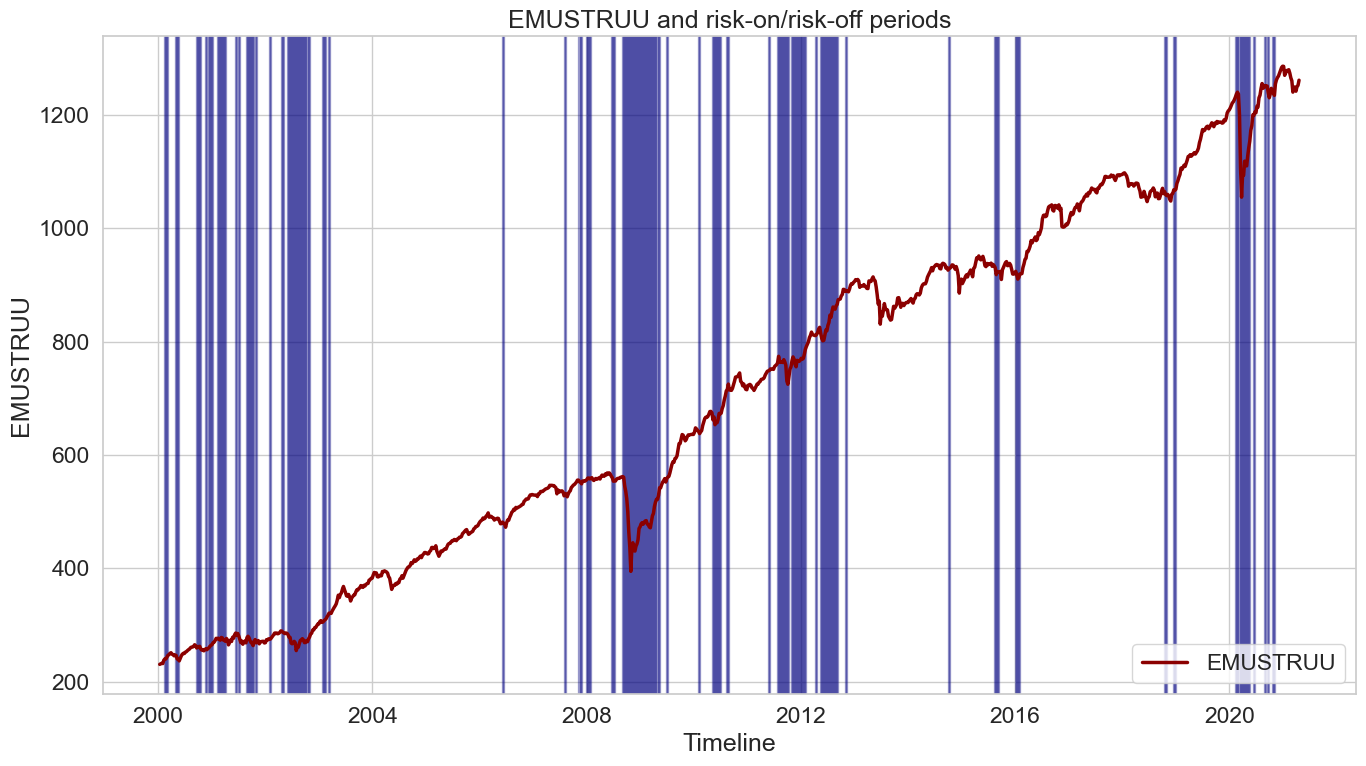

In [4]:
asset = 'EMUSTRUU'
Plot_riskperiod_asset(asset)

## The Greenback
We would assume that Dollar is somewhat sensitive and inversely correlated to risk off periods, i.e the dollar tends to have appreciate, in these periods as investors increase their exposures to safe haven assets like US government bonds.

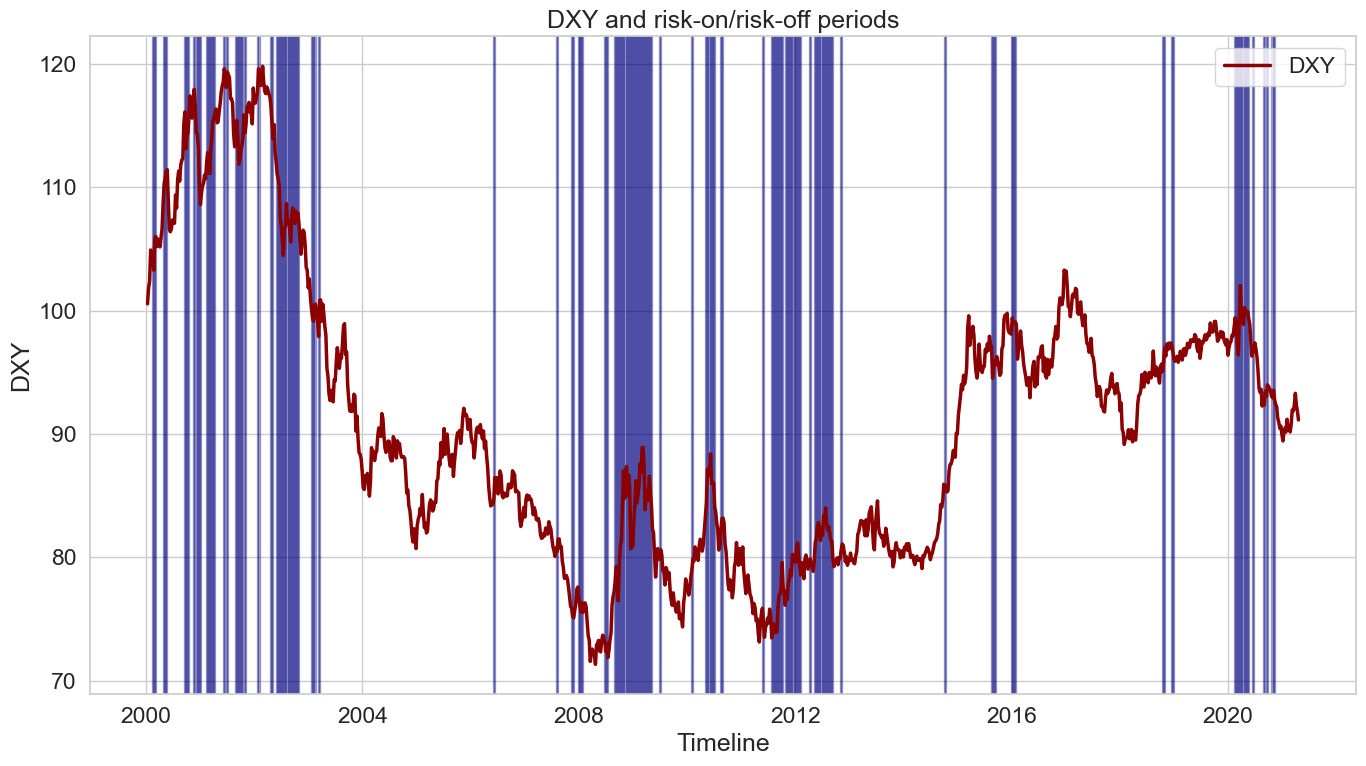

In [5]:
asset = 'DXY'
Plot_riskperiod_asset(asset)

In [6]:
data_df.head()

,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1


## Return Dataset

Price is not stationary in general and a non-stationary model is not just inaccurate — it’s structurally **wrong**.

## Stationarity Transformation

- **Indices and currencies**: log-differenced (they are strictly positive).
- **Interest rates and yields**: first differences (they can be negative or close to zero).
- **Economic surprise index**: left as is (already roughly stationary). Note: Do not take this as a rule for macroeconomic variables; many are non-stationary, sometimes they need to be differentiated TWICE (sic).


Only the **features** are transformed — not the labels, i.e., our vector Y.

In [7]:
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Create a new dataframe for stationary data
stationary_df = pd.DataFrame(index=X_df.index[1:])

# Apply log-differences to indices and currencies 
for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

# Apply first differences to interest rates (can be negative or very close to 0)
for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

if 'ECSURPUS' in X_df.columns:
    stationary_df['ECSURPUS'] = X_df['ECSURPUS'].values[1:]

if y is not None:
    y_stationary = y[1:]
else:
    y_stationary = None

stationary_df.head()
stationary_df["Y"] = y_stationary

# Correlation : Point-Biserial Correlation
We use  daily returns  rather than raw index prices. Prices are non-stationary and generally give fake, inflated correlations.
Correlation in our case is Point-Biserial Correlation.
### Core assumptions
For this correlation to be accurate, the data must meet specific criteria:
- Continuous Variable: The metric variable should be measured on an interval or ratio scale and be approximately normally distributed
- No Outliers: The continuous data should be free of extreme outliers.
- Homogeneity of Variance: The variance of the continuous variable should be roughly equal for both groups in the dichotomous variable

In [8]:
correlations = pd.DataFrame(stationary_df.corr()['Y'].sort_values())

print("Correlation with Risk-Off Regime (1):")
correlations

Correlation with Risk-Off Regime (1):


,Y
MXUS,-0.242428
LP01TREU,-0.209294
MXEU,-0.206401
GTDEM2Y,-0.200776
MXJP,-0.197236
GTGBP2Y,-0.196224
LG30TRUU,-0.178877
USGG2YR,-0.177489
LF98TRUU,-0.174037
MXBR,-0.168648


The top negative correlation we find is MXUS, which further incentivises a short thesis during risk off periods, there is also a *Self-fullfiling prophecy* component, in fact as market actors tend to believe that it is a risk off period, they reduce their exposures in US Equity markets, which drives negatives returns, this pushes other actors to also reduce their exposures as the phenomena propagates in markets.

Altough our correlations are all overall very weak, the most interesting finding is that `GT10` which is the US bond index has negative, in fact While -0.15 might still seem like a "weak" correlation in purely statistical terms, in the context of daily financial time series, it is a very solid building block for your Early Warning System. Bonds are less volatile: Government bond yields move in much smaller increments than equities or currencies. A correlation of -0.15 over a large dataset indicates a persistent, reliable structural shift in the bond market during crises.

In [9]:
metadata_df

,Variable name,Description,Type
0,Date,Calendar date,dd/mm/yy
1,XAU BGNL,Gold Spot $/Oz,Commodity
2,ECSURPUS,Bloomberg ECO US Surprise Inde,Economic Index
3,BDIY,Baltic Dry Index,Economic Index
4,CRY,TR/CC CRB ER Index,Commodity Index
5,DXY,DOLLAR INDEX SPOT,Currency
6,JPY,Japanese Yen Spot,Currency
7,GBP,British Pound Spot,Currency
8,Cl1,Generic 1st 'CL' Future,Commodity
9,VIX,Cboe Volatility Index,Volatility Index


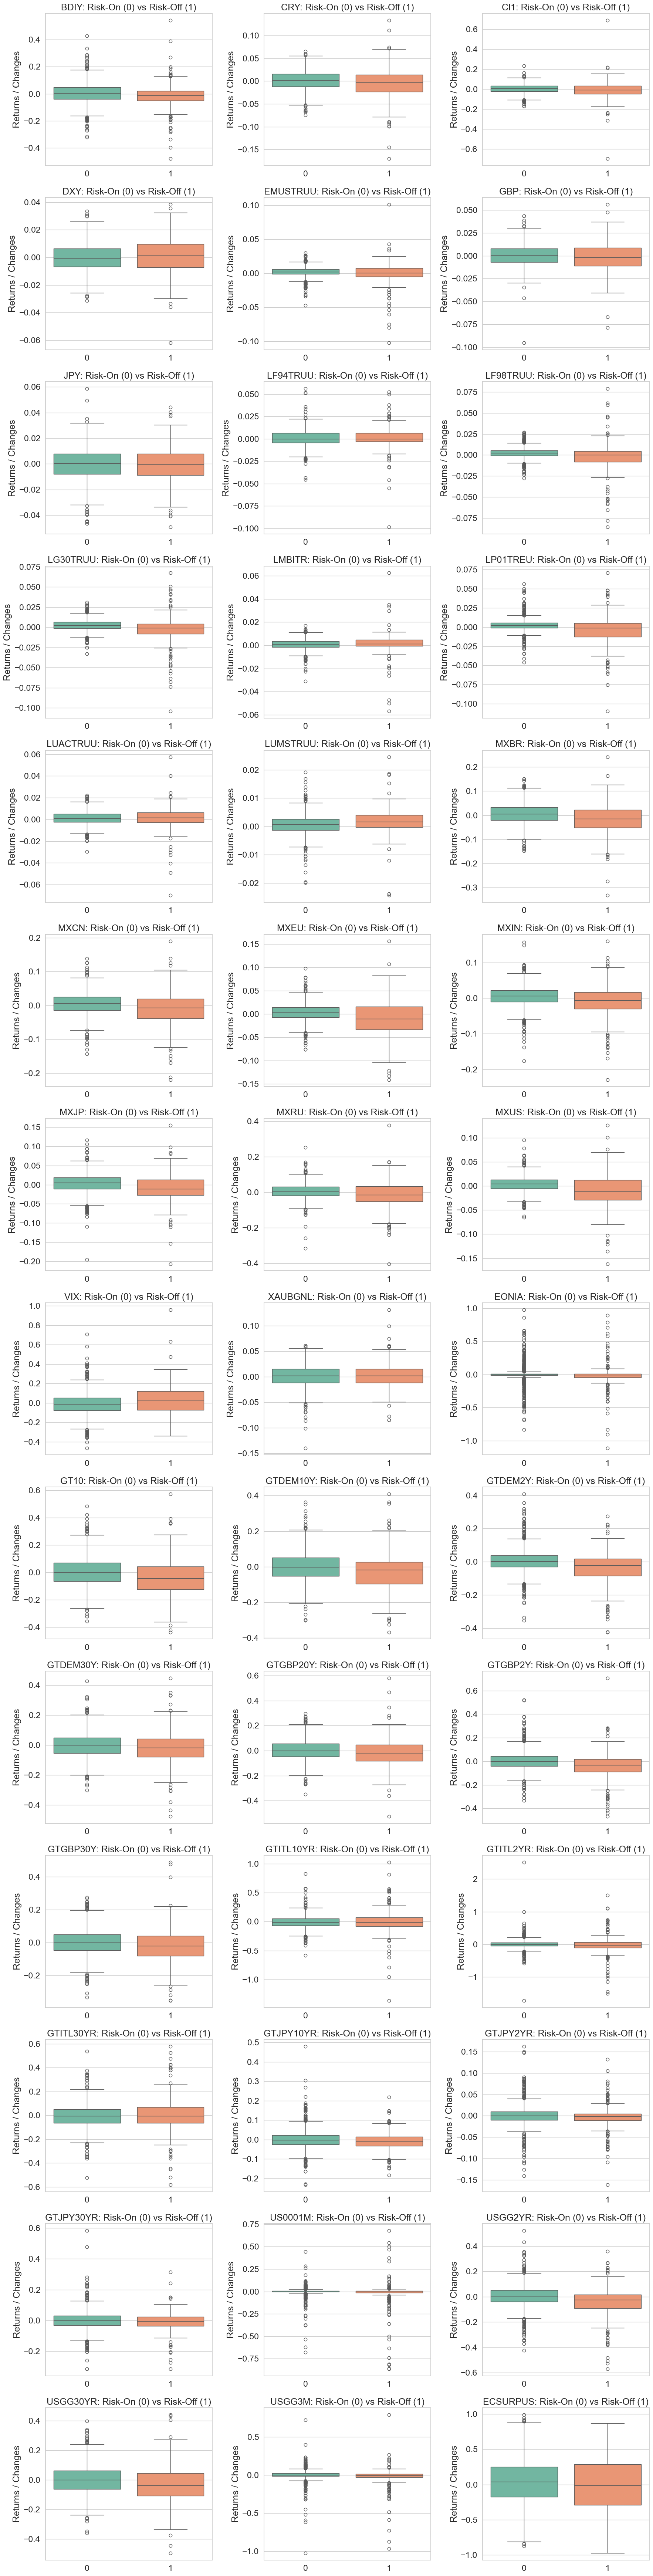

In [10]:
columns = stationary_df.columns.tolist()

plots_per_row = 3
num_rows = math.ceil(len(columns) / plots_per_row) -1

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(18, 5 * num_rows))

axes = axes.flatten()

for i, col in enumerate(columns):
    if col != "Y" :
        sns.boxplot(x=y_stationary, y=col, data=stationary_df, ax=axes[i], palette='Set2', hue=y_stationary, legend=False)
        axes[i].set_title(f'{col}: Risk-On (0) vs Risk-Off (1)')
        axes[i].set_ylabel('Returns / Changes')

# Clean up
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Distribution Skew and kurtosis
Some asset classes display significant difference in the distribution shape between Risk-on and Risk-off mode, for example  **BDIY : Baltic Dry Index - LG30TRUU : Global High Yield  - LMBITR : Municipal Bond Index ...**, in fact these high risk assets are generally the ones to get cut first in exposures from money managers worldwide. We Statistically test this hypothesis to identify assets that present a significant statistical difference between the two regimes : 

In [11]:
features = [col for col in stationary_df.columns if col != 'Y']
normality_results = []

for col in features:
    data = stationary_df[col].dropna()
    
    # Shapiro-Wilk Test
    stat_sw, p_sw = stats.shapiro(data)
    
    # Jarque-Bera Test (Excellent for financial returns)
    stat_jb, p_jb = stats.jarque_bera(data)
    
    # If p-value < 0.05, we reject H0, meaning the data is NOT normal.
    is_normal = "Yes" if p_jb > 0.05 else "No"
    
    normality_results.append({
        'Asset / Feature': col,
        'Shapiro Statistic': round(stat_sw, 4),
        'Shapiro p-value': p_sw,
        'Jarque-Bera p-value': p_jb,
        'Normally Distributed?': is_normal
    })

#  Convert to a DataFrame and display
results_df = pd.DataFrame(normality_results)
display(results_df)

,Asset / Feature,Shapiro Statistic,Shapiro p-value,Jarque-Bera p-value,Normally Distributed?
0,BDIY,0.9539,3.395016e-18,7.202171e-170,No
1,CRY,0.9585,3.241155e-17,1.231482e-210,No
2,Cl1,0.8455,1.536525e-31,0.000000e+00,No
3,DXY,0.9923,1.517948e-05,7.168259e-13,No
4,EMUSTRUU,0.8039,1.245775e-34,0.000000e+00,No
5,GBP,0.9647,9.196999e-16,8.052297e-211,No
6,JPY,0.9890,2.163356e-07,2.244073e-17,No
7,LF94TRUU,0.9061,1.419473e-25,0.000000e+00,No
8,LF98TRUU,0.7881,1.143827e-35,0.000000e+00,No
9,LG30TRUU,0.8210,1.974683e-33,0.000000e+00,No


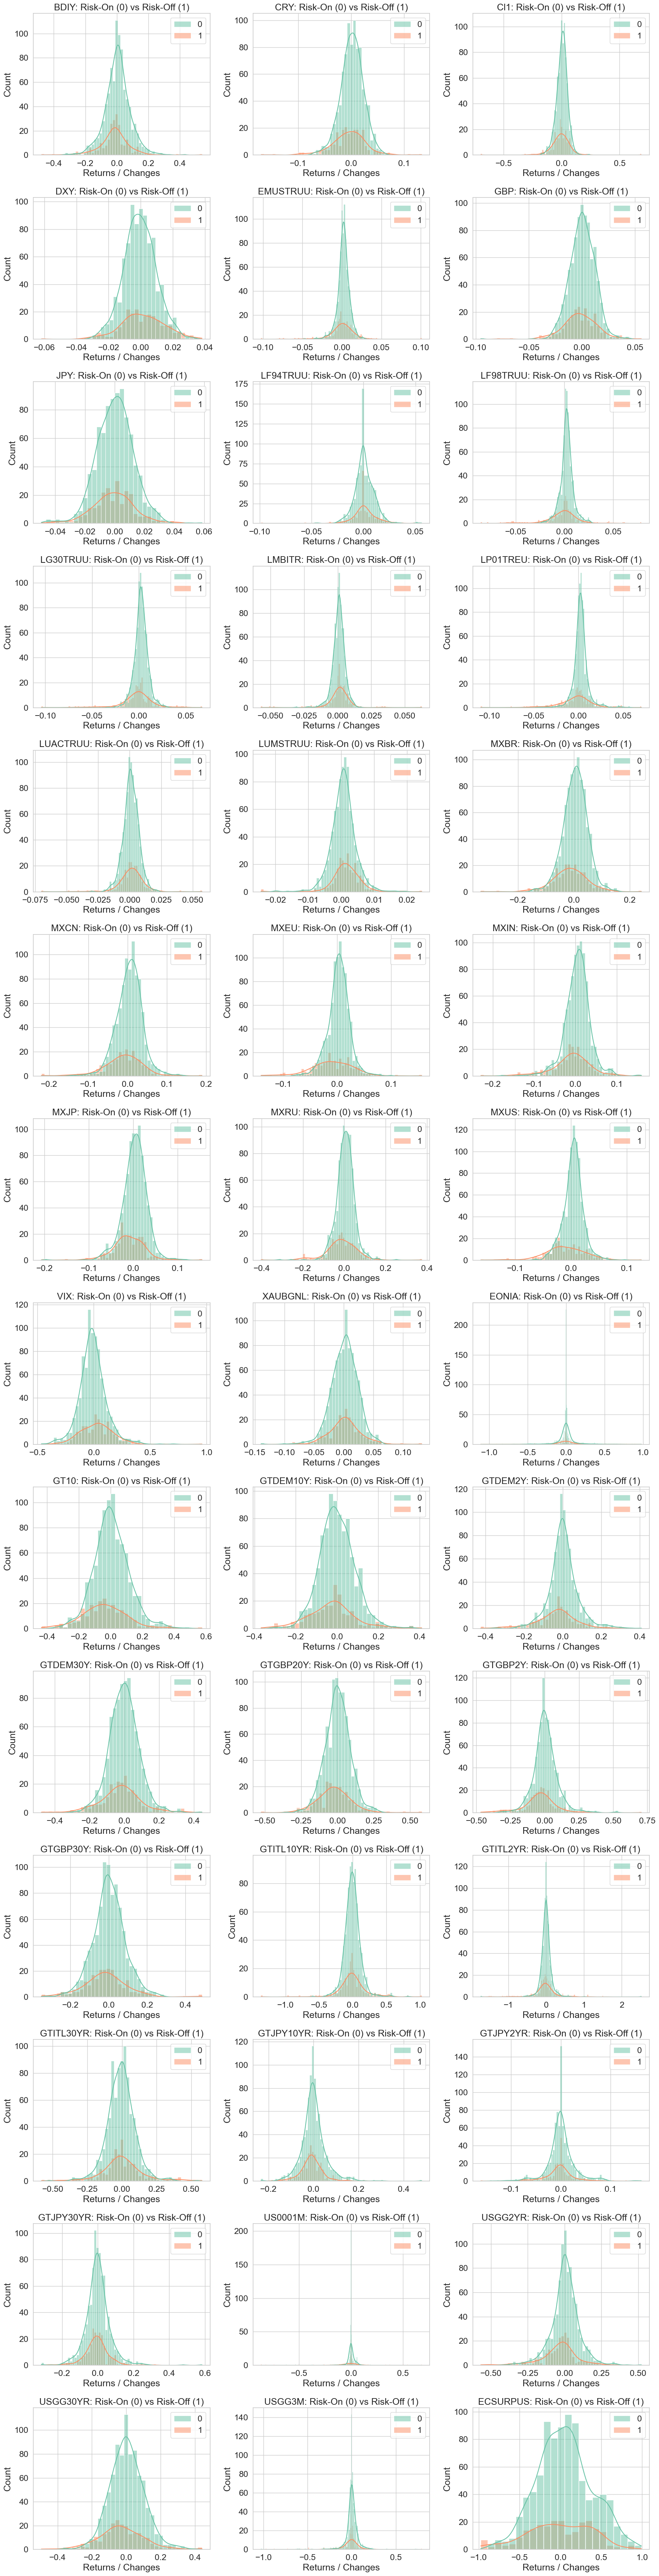

In [12]:
plot_columns = [col for col in stationary_df.columns if col != "Y"]

plots_per_row = 3
num_rows = math.ceil(len(plot_columns) / plots_per_row)

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    sns.histplot(
        data=stationary_df, 
        x=col, 
        hue=y_stationary,      
        ax=axes[i], 
        palette='Set2',
        kde=True,             
        alpha=0.5              
    )
    
    axes[i].set_title(f'{col}: Risk-On (0) vs Risk-Off (1)')
    axes[i].set_xlabel('Returns / Changes')
    axes[i].set_ylabel('Count') 

for j in range(len(plot_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
# Prepare a list to store the results
mean_test_results = []

# Get all columns except the target "Y"
features = [col for col in stationary_df.columns if col != 'Y']

for col in features:
    # Split the data into the two regimes based on the target variable
    risk_on_data = stationary_df[stationary_df['Y'] == 0][col].dropna()
    risk_off_data = stationary_df[stationary_df['Y'] == 1][col].dropna()
    
    # 1. Welch's t-test (Tests for difference in MEANS, assumes unequal variance)
    t_stat, p_val_t = stats.ttest_ind(risk_on_data, risk_off_data, equal_var=False)
    
    # 2. Mann-Whitney U test (Tests for difference in DISTRIBUTIONS, ignores non-normality)
    u_stat, p_val_u = stats.mannwhitneyu(risk_on_data, risk_off_data, alternative='two-sided')
    
    # Determine if the difference is statistically significant (p-value < 0.05)
    significant_diff = "Yes" if p_val_t < 0.05 else "No"
    
    # Append the results
    mean_test_results.append({
        'Asset': col,
        'Risk-On Mean': round(risk_on_data.mean(), 5),
        'Risk-Off Mean': round(risk_off_data.mean(), 5),
        't-test p-value': p_val_t,
        'Mann-Whitney p-value': p_val_u,
        'Significant Difference?': significant_diff
    })

# Convert to DataFrame and display
results_df = pd.DataFrame(mean_test_results)
display(results_df)

,Asset,Risk-On Mean,Risk-Off Mean,t-test p-value,Mann-Whitney p-value,Significant Difference?
0,BDIY,0.00513,-0.01654,3.065909e-03,2.911569e-04,Yes
1,CRY,0.00170,-0.00536,3.235520e-03,2.053023e-03,Yes
2,Cl1,0.00375,-0.01007,3.170663e-02,5.073436e-03,Yes
3,DXY,-0.00043,0.00118,9.573303e-02,5.078477e-02,No
4,EMUSTRUU,0.00205,-0.00036,4.233131e-02,2.698689e-02,Yes
5,GBP,0.00035,-0.00197,4.673067e-02,2.535659e-02,Yes
6,JPY,0.00029,-0.00097,2.160571e-01,2.027385e-01,No
7,LF94TRUU,0.00104,0.00109,9.560431e-01,6.804568e-01,No
8,LF98TRUU,0.00230,-0.00225,3.073374e-04,9.349008e-08,Yes
9,LG30TRUU,0.00246,-0.00228,1.548312e-04,9.325488e-08,Yes


In [14]:
significant_assets_df = results_df[results_df["Significant Difference?"] == "Yes"]

# 2. Extract the list of asset names
assets_to_keep = significant_assets_df["Asset"].tolist()
filtered_df = stationary_df[assets_to_keep + ["Y"]]

### Modelling approach for best possible detection
Our data exploration findings support a feature selection thesis, in fact we assume that our modelling framework of the Data generating process is Dense, in fact the industry standard by Portfolio Managers is that **macroeconomic forecasting is not a sparse prediction exercise.** 

So in order to extract as much signal as possible, our thesis is the following : 

**Select the features that provide the best signal to noise ratio, this hypothesis will be tested, and if it doesnt provide better results we will revert back to modelling using the whole dataset because in that case our target is driven by "latent" factors that manifest themselves across many different variables**

# Novelty Detection Modelling

## Raw Feature Selection : Using Assets with significant variability difference between regimes for Discriminating Power

Idea would be to use only assets with high variability between the risk-off and risk-on periods, the assumption being they carry more discriminating power, in fact by eliminating assets with no significant difference in variability, reduces noise in the system, thus improving the Signal-to-Noise ratio.

In [15]:
# Hiding the labels from the model Unsupervised 
X = filtered_df.drop(columns=['Y'])
y_true = filtered_df['Y'] 

# train the Isolation Forest
# contamination: The estimated percentage of outliers in your dataset 
iso_forest = IsolationForest(contamination=0.05, random_state=42)
y_pred_if_raw = iso_forest.fit_predict(X) 

# train the One-Class SVM
# nu: Similar to contamination, an upper bound on the fraction of training errors 
# and a lower bound of the fraction of support vectors.
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
y_pred_svm_raw = oc_svm.fit_predict(X)

# Scikit-learn unsupervised models return:
#  1 for INLIERS (Normal Market / Risk-On)
# -1 for OUTLIERS (Anomaly / Risk-Off)
# We need to map these to your survey labels: 0 for Risk-On, 1 for Risk-Off

def map_predictions(preds):
    return np.where(preds == -1, 1, 0)

y_pred_if = map_predictions(y_pred_if_raw)
y_pred_svm = map_predictions(y_pred_svm_raw)

# Evaluate against the hidden Survey Data
print("--- ISOLATION FOREST Evaluation ---")
print(classification_report(y_true, y_pred_if))

print("\n--- ONE-CLASS SVM Evaluation ---")
print(classification_report(y_true, y_pred_svm))

--- ISOLATION FOREST Evaluation ---
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       873
           1       0.73      0.17      0.28       237

    accuracy                           0.81      1110
   macro avg       0.77      0.58      0.59      1110
weighted avg       0.80      0.81      0.76      1110


--- ONE-CLASS SVM Evaluation ---
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       873
           1       0.62      0.16      0.25       237

    accuracy                           0.80      1110
   macro avg       0.71      0.56      0.57      1110
weighted avg       0.77      0.80      0.75      1110



### Remarks
- Both models are exhibiting the exact same behavior: They are highly accurate during normal times, but they are missing the vast majority of the crises.

- The stark difference between Class 0 (Risk-On / Normal) and Class 1 (Risk-Off / Crisis)

- Support: Dataset has 873 Normal days and 237 Crisis days. we have an imbalanced dataset (about 79% normal, 21% crisis).

- Accuracy: Both models show ~80% overall accuracy. In imbalanced anomaly detection, accuracy is a trap. in fact If the model just lazily guessed "0" every single day, it would get 79% accuracy. Precision and Recall for Class 1 present a much better image.

- Recall = 17% : Out of the 237 actual "Risk-Off" days, the Isolation Forest only caught 17% of them (~40 days). It completely missed the other 197 crisis days. The model is effectively "asleep at the wheel" for most of the turbulent periods.

- Precision = 73% : When the model does ring the alarm and flag a day as an anomaly, it is right 73% of the time. This means the model isn't outputting random noise; when it sees a crisis, it is genuinely a crisis. It's just very hesitant to push the button.


**We proceed with a mechanical improvement proceduce, We tune the contamination parameter usin Cross-Validation :**

In [16]:
# Setup Time Series Cross-Validation 
tscv = TimeSeriesSplit(n_splits=5)

# Define the parameter grid to test
contamination_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Prepare data 
X = stationary_df.drop(columns=['Y'])
y = stationary_df['Y']

cv_results = []

for contam in contamination_grid:
    f1_scores = []
    recalls = []
    precisions = []
    
    # Iterate chronologically through time
    for train_index, test_index in tscv.split(X):
        # Split data without shuffling
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_test = y.iloc[test_index] 
        
        # Train the unsupervised model
        model = IsolationForest(contamination=contam, random_state=42)
        model.fit(X_train)
        
        # Predict on the unseen future time split
        preds_raw = model.predict(X_test)
        
        # Map output: -1 (Anomaly) becomes 1 (Risk-Off), 1 (Normal) becomes 0
        preds = np.where(preds_raw == -1, 1, 0) 
        
        # Grade the performance
        f1_scores.append(f1_score(y_test, preds, zero_division=0))
        recalls.append(recall_score(y_test, preds, zero_division=0))
        precisions.append(precision_score(y_test, preds, zero_division=0))
        
    # Average the performance across all 5 time-splits
    cv_results.append({
        'Contamination Parameter': contam,
        'Avg F1-Score': np.mean(f1_scores),
        'Avg Recall (Crises Caught)': np.mean(recalls),
        'Avg Precision (True Alarms)': np.mean(precisions)
    })

#  View Results
results_df = pd.DataFrame(cv_results)

print("--- Time Series Cross Validation Results ---")
# Sort by F1-Score (The balance between Precision and Recall)
display(results_df.sort_values(by='Avg F1-Score', ascending=False))

--- Time Series Cross Validation Results ---


,Contamination Parameter,Avg F1-Score,Avg Recall (Crises Caught),Avg Precision (True Alarms)
5,0.30,0.328341,0.367482,0.310809
4,0.25,0.321553,0.335008,0.328269
3,0.20,0.299665,0.287608,0.329725
2,0.15,0.286880,0.254031,0.361905
1,0.10,0.246365,0.197798,0.366978
0,0.05,0.221236,0.158426,0.492338


In [17]:
# 1. Prepare the data 
X = filtered_df.drop(columns=['Y'])

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
pca = PCA() # Not specifying n_components means it keeps all of them
X_pca = pca.fit_transform(X_scaled)

pc_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_columns, index=X.index)

explained_variance = pca.explained_variance_ratio_
for i, var in enumerate(explained_variance):
    print(f"PC{i+1} explains {var*100:.2f}% of the variance")

iso_forest_pca = IsolationForest(contamination=0.30, random_state=42)
preds_raw = iso_forest_pca.fit_predict(df_pca)

PC1 explains 28.42% of the variance
PC2 explains 16.72% of the variance
PC3 explains 5.84% of the variance
PC4 explains 4.89% of the variance
PC5 explains 4.66% of the variance
PC6 explains 4.37% of the variance
PC7 explains 3.44% of the variance
PC8 explains 3.28% of the variance
PC9 explains 3.00% of the variance
PC10 explains 2.78% of the variance
PC11 explains 2.54% of the variance
PC12 explains 2.40% of the variance
PC13 explains 2.30% of the variance
PC14 explains 1.87% of the variance
PC15 explains 1.63% of the variance
PC16 explains 1.52% of the variance
PC17 explains 1.41% of the variance
PC18 explains 1.29% of the variance
PC19 explains 1.19% of the variance
PC20 explains 1.15% of the variance
PC21 explains 1.00% of the variance
PC22 explains 0.89% of the variance
PC23 explains 0.77% of the variance
PC24 explains 0.71% of the variance
PC25 explains 0.58% of the variance
PC26 explains 0.48% of the variance
PC27 explains 0.40% of the variance
PC28 explains 0.21% of the variance

--- FINAL MODEL: PCA + ISOLATION FOREST ---
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       873
           1       0.41      0.58      0.48       237

    accuracy                           0.73      1110
   macro avg       0.64      0.68      0.65      1110
weighted avg       0.77      0.73      0.75      1110



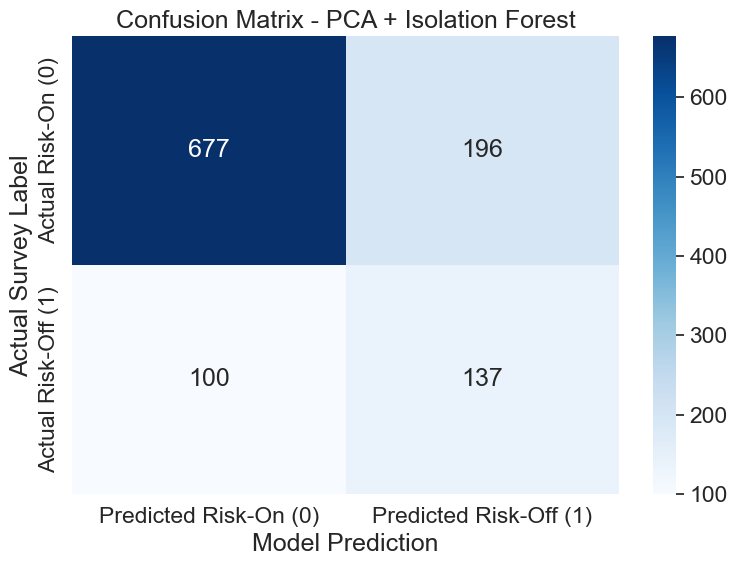

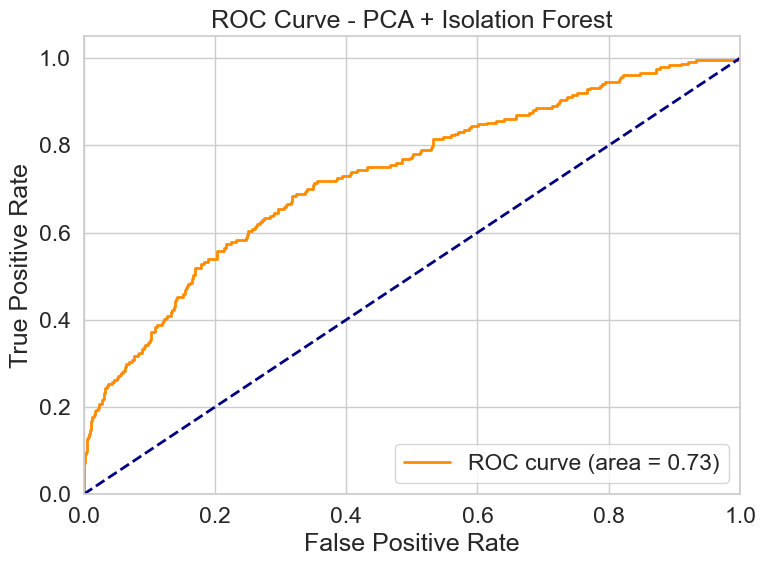

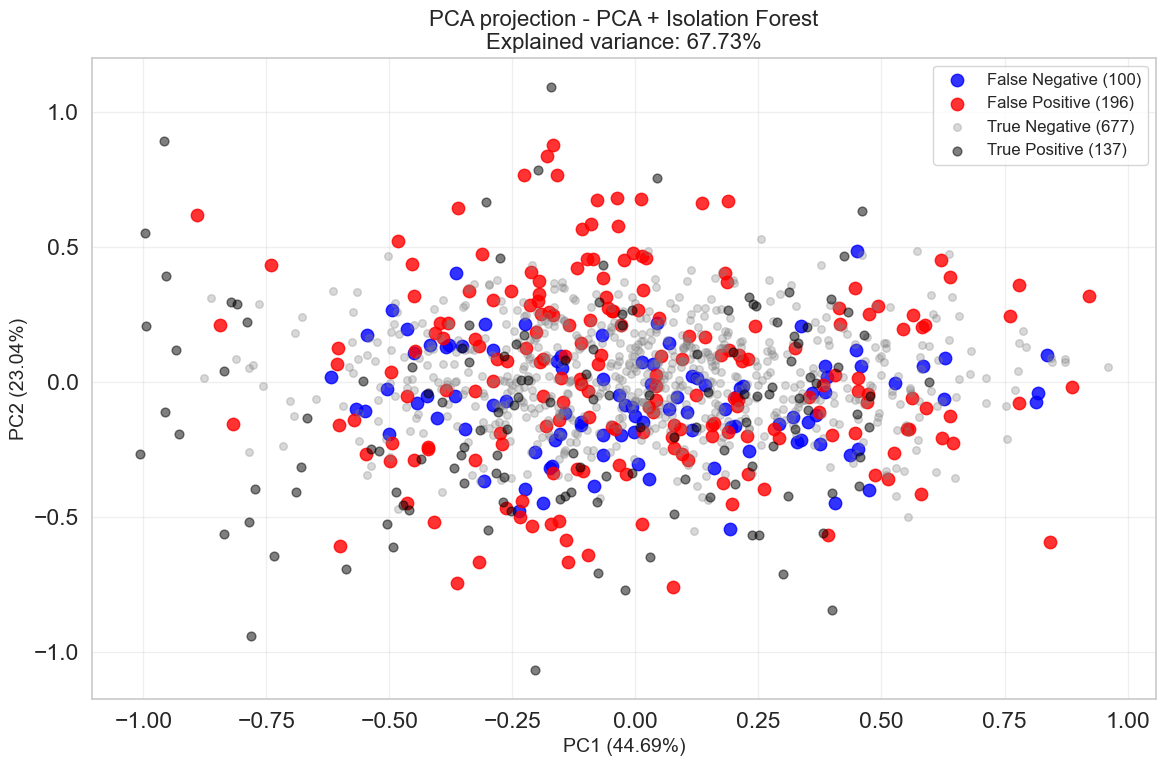

In [18]:
# 1. Initialize the Isolation Forest
final_model = IsolationForest(contamination=0.30, random_state=42)

# 2. Train and Predict on the Principal Components
preds_raw = final_model.fit_predict(df_pca)

# 3. Map the outputs to Survey Labels
# Scikit-learn outputs -1 for Anomaly, 1 for Normal
# We map them to 1 (Risk-Off) and 0 (Risk-On)
y_pred_final = np.where(preds_raw == -1, 1, 0)

# 4. Extract true labels for evaluation
y_true = filtered_df['Y']

# --- EVALUATION ---
print("--- FINAL MODEL: PCA + ISOLATION FOREST ---")
print(classification_report(y_true, y_pred_final))

y_score_iso = -final_model.decision_function(df_pca)


evaluate_model(y_true, y_pred_final, y_score_iso, "PCA + Isolation Forest")

# PCA plots
visualize_pca(X, y_true.values, y_pred_final, "PCA + Isolation Forest")



## Autoencoder

An **Autoencoder** is a type of **neural network** designed to learn a compressed representation of the data.

It consists of:

- An **encoder**: reduces the input to a lower-dimensional space (the **bottleneck**).
- A **decoder**: reconstructs the input from this compressed version.

The result is a model that learns to **encode the structure of normal data**.

Autoencoders belong to the family of **latent variable models**, just like:

- **PCA** (which finds linear projections).
- **Factor models** (which assume a linear dependence on unobserved factors).

However, an autoencoder can model **highly nonlinear structures** in the data,  
thanks to the expressive power of neural networks.

> The **bottleneck** forces the network to compress information.  
> The model must learn what's essential — and discard the rest.

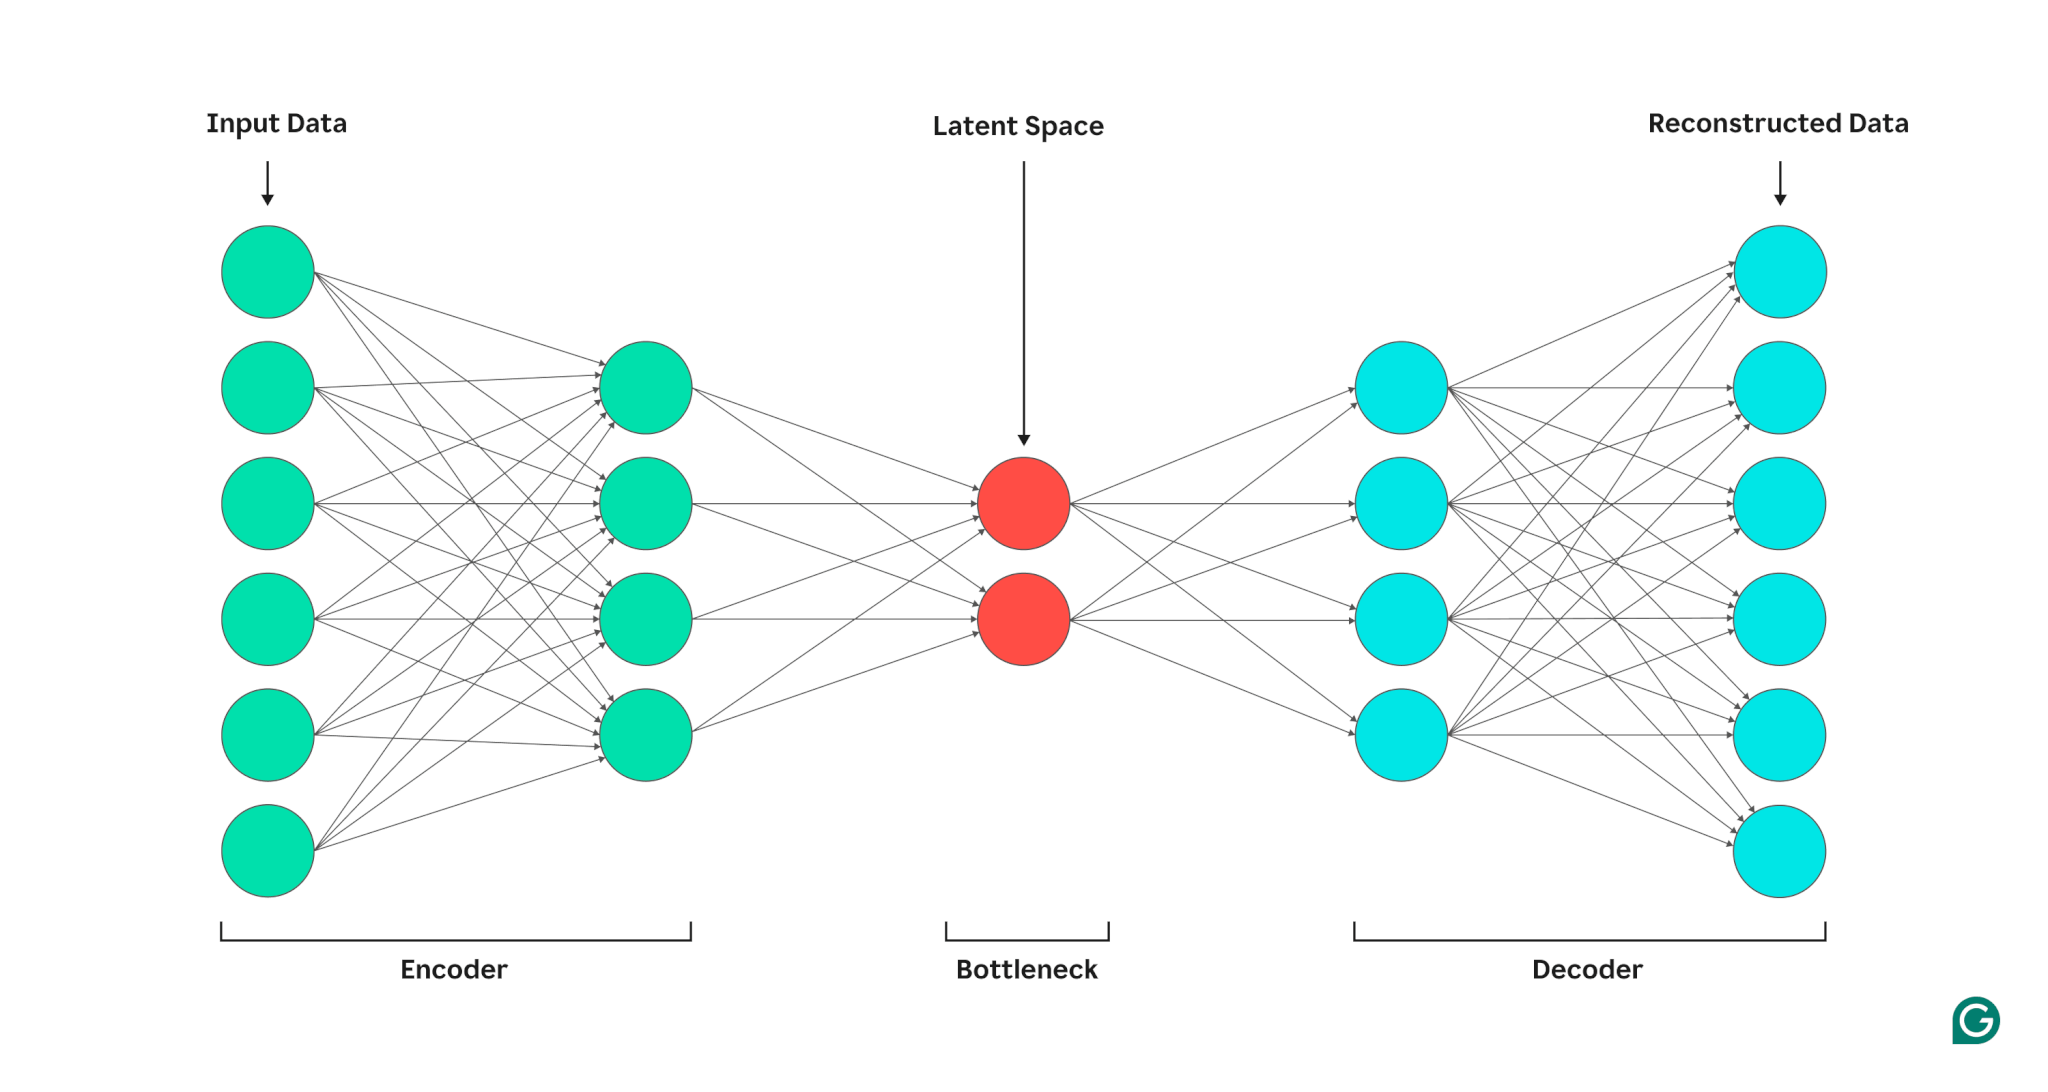


In order to extract the highest possible signal-to-noise ratio and optimize our anomaly detection, we will test the Deep Learning model (Autoencoder) on two different representations of our data. 

To scientifically evaluate this assumption, we will run the Autoencoder pipeline **twice**:

1. **Full Dataset - `stationary_df`**: 
   We feed the neural network *all* available macroeconomic features.
   
2. **Filtered Dataset - `filtered_df`**: 
   We feed the model *only* the features that showed a statistically significant variance difference between Risk-On and Risk-Off regimes (identified earlier via statistical tests). The assumption is that by manually removing "noisy" variables, we improve the signal-to-noise ratio and make it easier for the network to spot the anomalies.


## Full Dataset  - `stationary_df`

In [19]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Convert to numpy arrays for easier manipulation
X = stationary_df.drop(columns=['Y']).values
y = stationary_df['Y'].values

# Reshuffle the data (this will break down autocorrelation)
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate normal and anomalous examples
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

# Calculate sizes for each set
n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Training set: 80% of normal examples
train_size = int(0.8 * n_normal)
X_train = X_normal[:train_size]

# Cross-validation set: 10% of normal examples and 50% of anomalies
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

# Test set: 10% of normal examples and 50% of anomalies
X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test = np.vstack((X_test_normal, X_test_anomaly))
y_test = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# We'll standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cv_scaled = scaler.transform(X_cross_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} (all normal)")
print(f"Cross-validation set size: {X_cross_val.shape[0]} ({cv_normal_size} normal, {cv_anomaly_size} anomalies)")
print(f"Test set size: {X_test.shape[0]} ({len(X_test_normal)} normal, {len(X_test_anomaly)} anomalies)")

Training set size: 698 (all normal)
Cross-validation set size: 205 (87 normal, 118 anomalies)
Test set size: 207 (88 normal, 119 anomalies)


Using device: cpu
Input dimension: 42 | Bottleneck dimension: 10
Training autoencoder...
Epoch 10/200, Loss: 0.942329
Epoch 20/200, Loss: 0.844345
Epoch 30/200, Loss: 0.798002
Epoch 40/200, Loss: 0.771717
Epoch 50/200, Loss: 0.738854
Epoch 60/200, Loss: 0.731596
Epoch 70/200, Loss: 0.737884
Epoch 80/200, Loss: 0.730934
Epoch 90/200, Loss: 0.714550
Epoch 100/200, Loss: 0.721247
Epoch 110/200, Loss: 0.715901
Epoch 120/200, Loss: 0.717926
Epoch 130/200, Loss: 0.706587
Epoch 140/200, Loss: 0.714599
Epoch 150/200, Loss: 0.705238
Epoch 160/200, Loss: 0.704636
Epoch 170/200, Loss: 0.699836
Early stopping at epoch 177


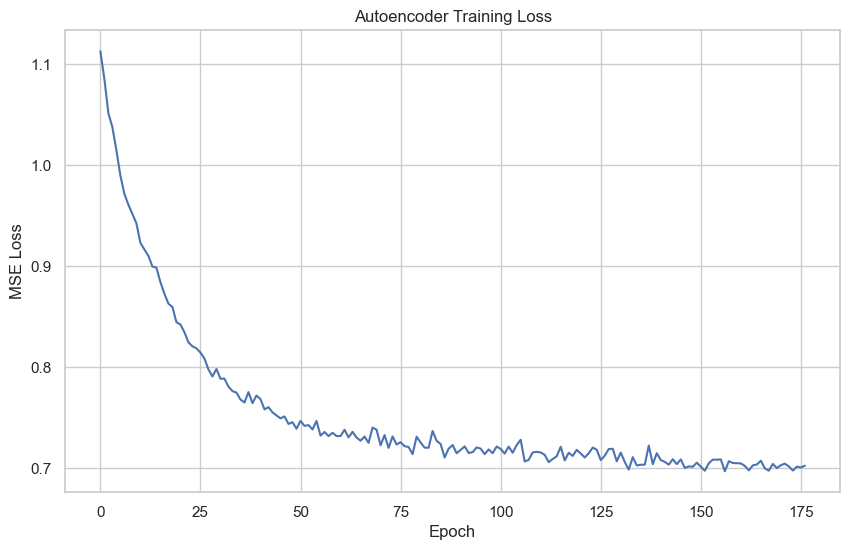

Contamination rate: 0.5756 | Anomaly Threshold: 0.585832

Autoencoder performance:
Precision: 0.6960
Recall: 0.7311
F1 Score: 0.7131


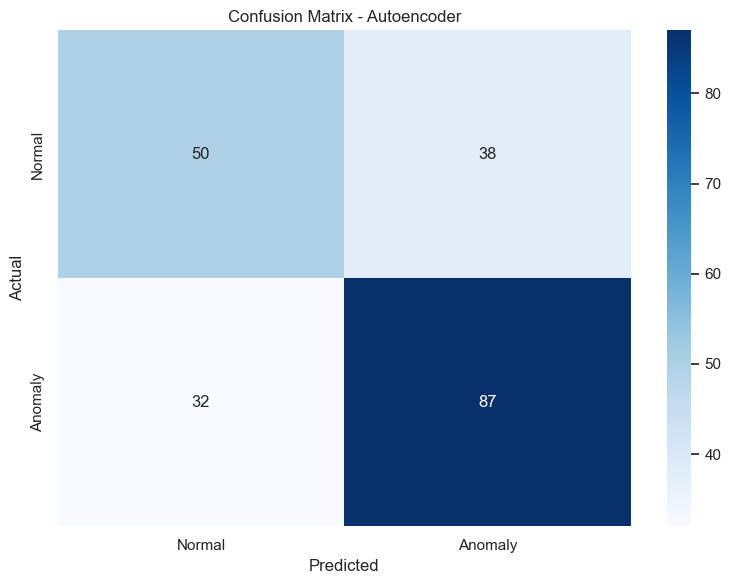

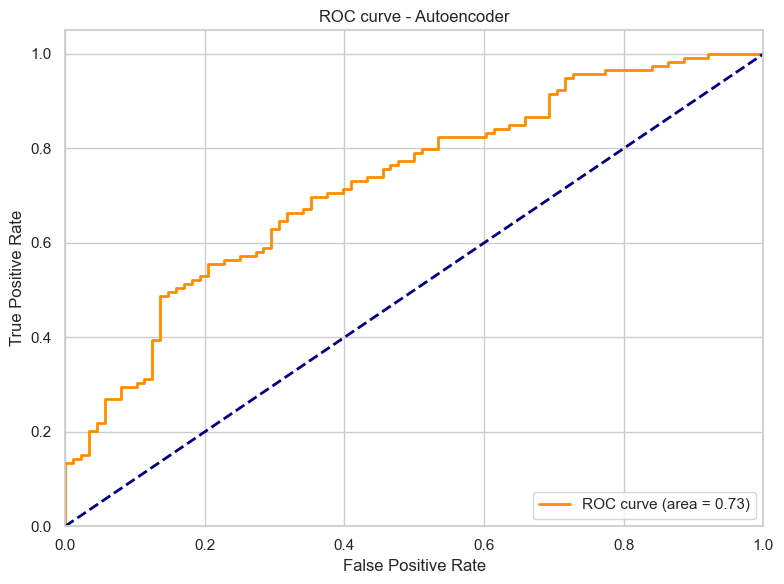

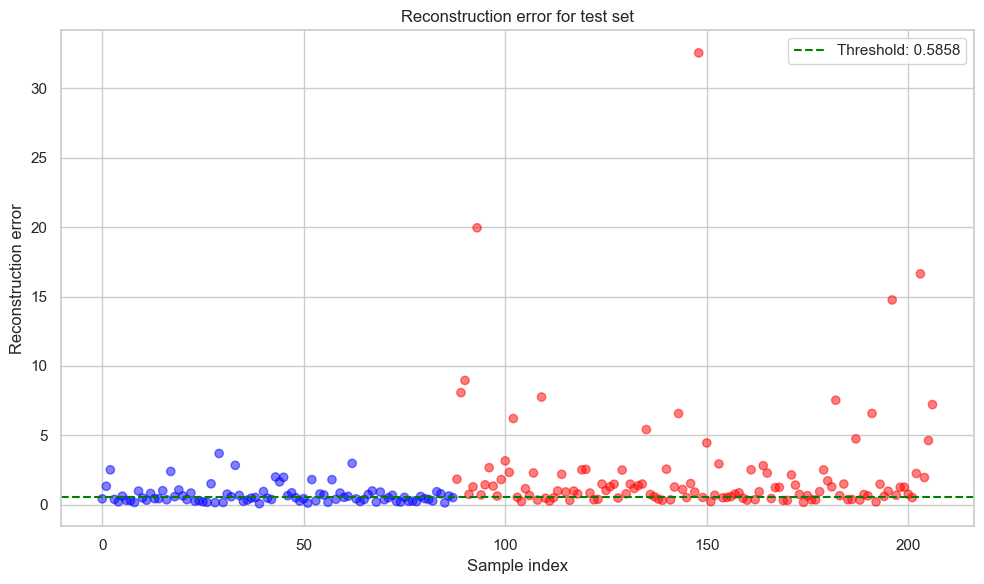

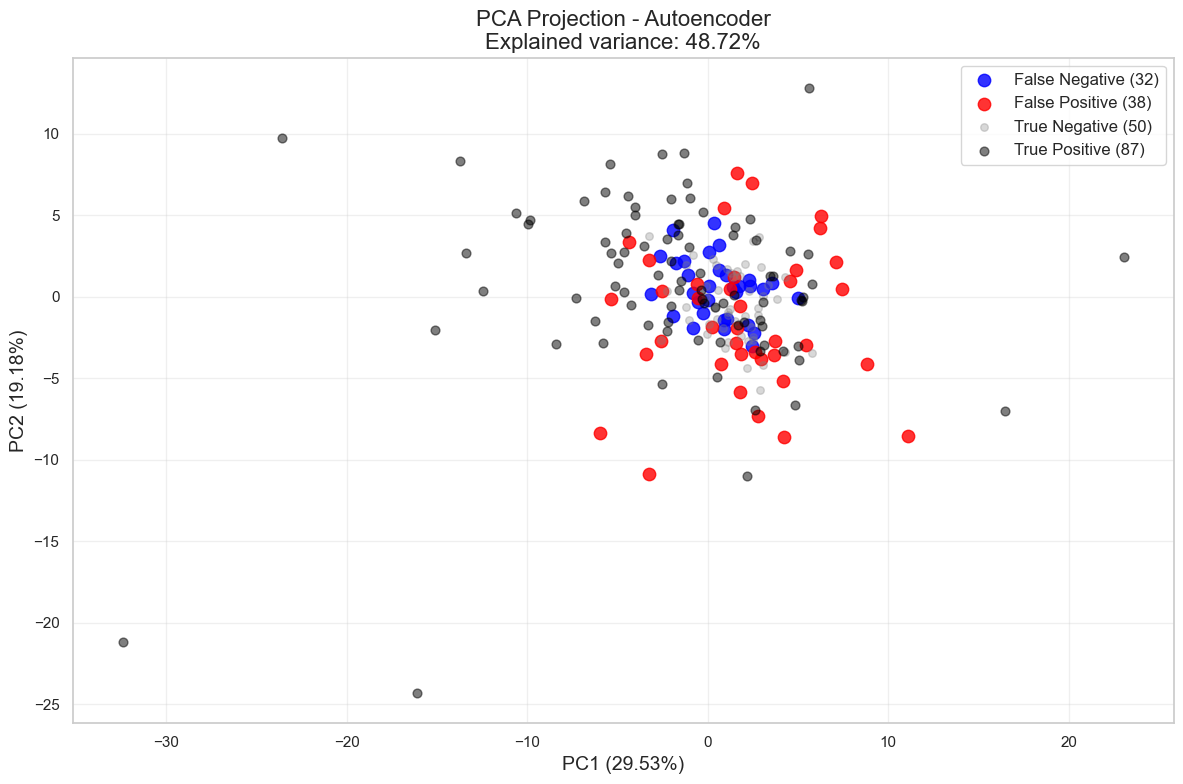

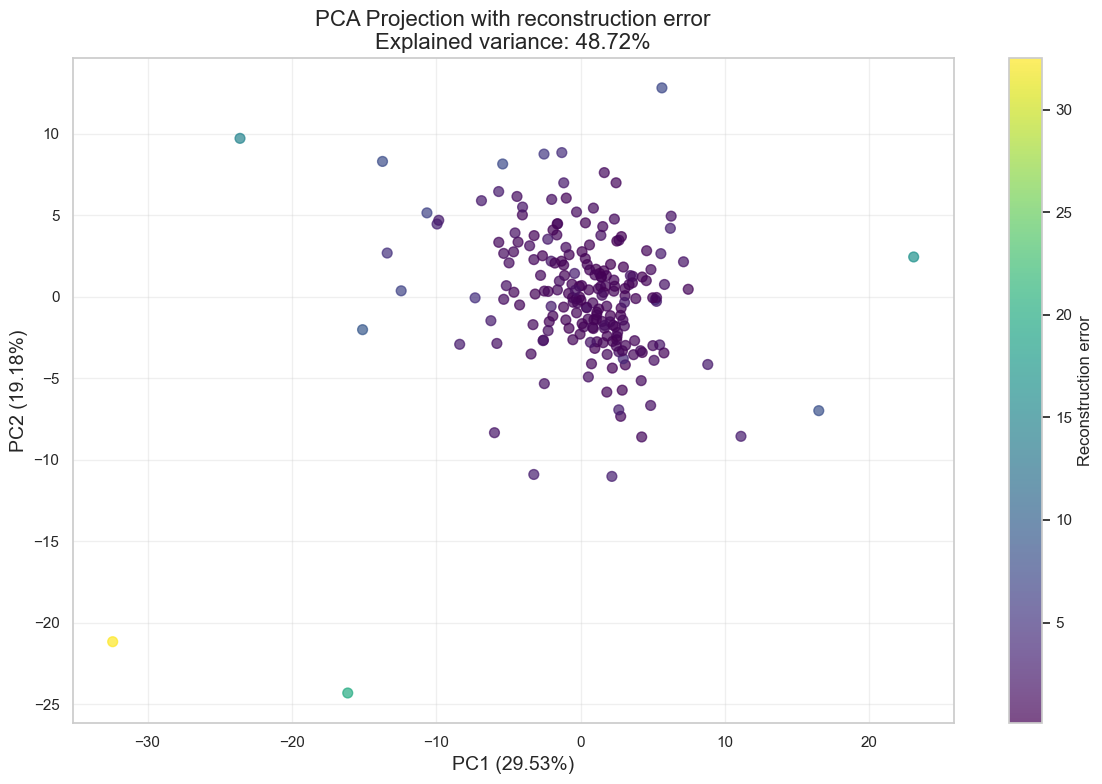

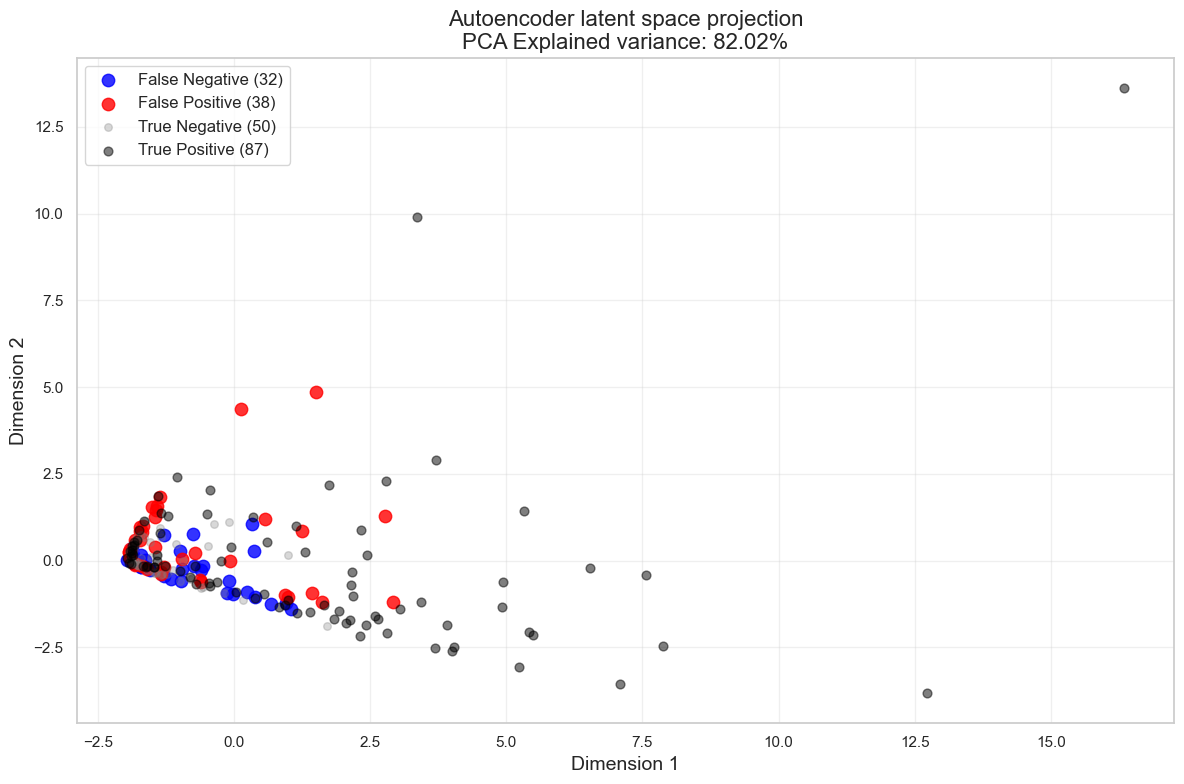

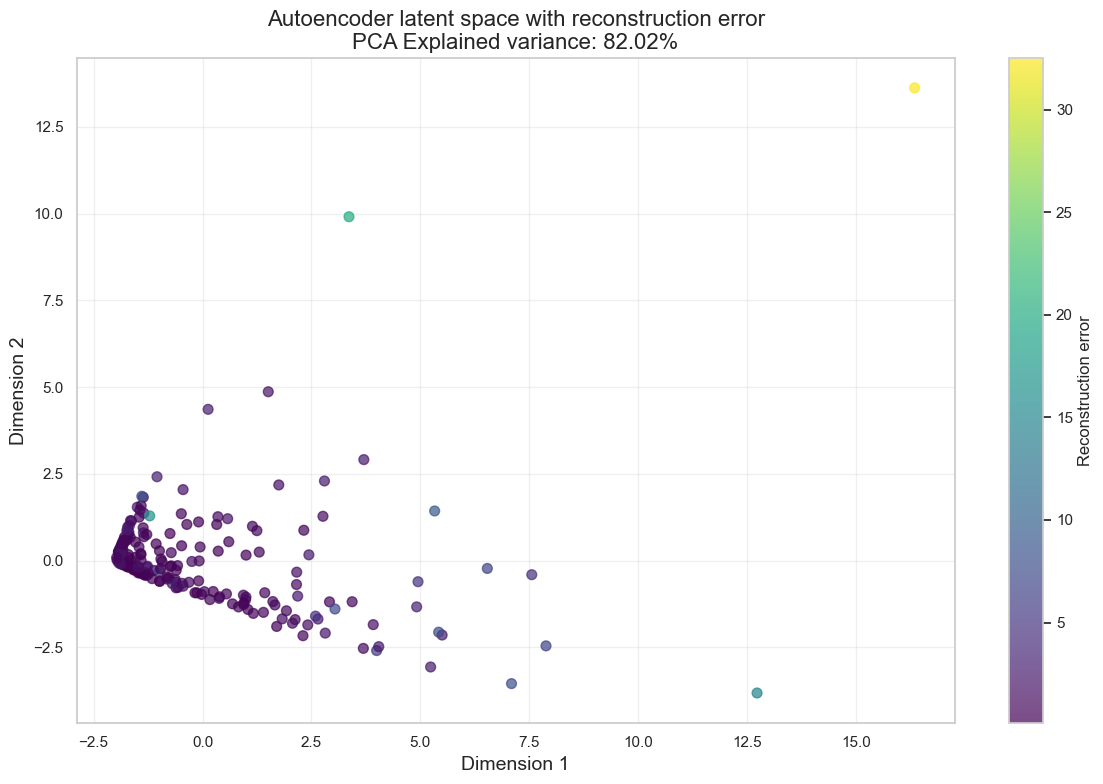

In [20]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_cv_tensor = torch.FloatTensor(X_cv_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# Create the autoencoder model
input_dim = X_train_scaled.shape[1]
encoding_dim = max(1, min(16, input_dim // 4))
model = Autoencoder(input_dim, encoding_dim).to(device)
print(f"Input dimension: {input_dim} | Bottleneck dimension: {encoding_dim}")

# Train the autoencoder
model = train_autoencoder(model, train_loader, num_epochs=200, patience=20)

# Compute reconstruction errors
cv_errors = compute_reconstruction_error(model, X_cv_tensor)
test_errors = compute_reconstruction_error(model, X_test_tensor)

# Set threshold at the percentile corresponding to the contamination rate
contamination = np.mean(y_cross_val)
threshold = np.percentile(cv_errors, 100 * (1 - contamination))
print(f"Contamination rate: {contamination:.4f} | Anomaly Threshold: {threshold:.6f}")

# Make predictions on test set
y_pred = (test_errors > threshold).astype(int)

# Plots
y_test_arr = np.array(y_test)
ae_metrics = evaluate_autoencoder(y_test_arr, y_pred, test_errors, threshold)
visualize_autoencoder_pca(model, X_test_tensor, X_test_scaled, y_test_arr, y_pred, test_errors)


## Filtered Dataset - `filtered_df`

In [21]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Convert to numpy arrays for easier manipulation
X_filtered = filtered_df.drop(columns=['Y']).values
y_filtered = filtered_df['Y'].values

# Reshuffle the data (this will break down autocorrelation)
X_shuffled_filtered, y_shuffled_filtered = shuffle(X_filtered, y_filtered, random_state=42)

# Separate normal and anomalous examples
X_normal_filtered = X_shuffled_filtered[y_shuffled_filtered == 0]
X_anomaly_filtered = X_shuffled_filtered[y_shuffled_filtered == 1]

# Calculate sizes for each set
n_normal_filtered = X_normal_filtered.shape[0]
n_anomaly_filtered = X_anomaly_filtered.shape[0]

# Training set: 80% of normal examples
train_size_filtered = int(0.8 * n_normal_filtered)
X_train_filtered = X_normal_filtered[:train_size_filtered]

# Cross-validation set: 10% of normal examples and 50% of anomalies
cv_normal_size_filtered = int(0.1 * n_normal_filtered)
cv_anomaly_size_filtered = int(0.5 * n_anomaly_filtered)
X_cv_normal_filtered = X_normal_filtered[train_size_filtered:train_size_filtered + cv_normal_size_filtered]
X_cv_anomaly_filtered = X_anomaly_filtered[:cv_anomaly_size_filtered]
X_cross_val_filtered = np.vstack((X_cv_normal_filtered, X_cv_anomaly_filtered))
y_cross_val_filtered = np.hstack((np.zeros(cv_normal_size_filtered), np.ones(cv_anomaly_size_filtered)))

# Test set: 10% of normal examples and 50% of anomalies
X_test_normal_filtered = X_normal_filtered[train_size_filtered + cv_normal_size_filtered:]
X_test_anomaly_filtered = X_anomaly_filtered[cv_anomaly_size_filtered:]
X_test_filtered = np.vstack((X_test_normal_filtered, X_test_anomaly_filtered))
y_test_filtered = np.hstack((np.zeros(len(X_test_normal_filtered)), np.ones(len(X_test_anomaly_filtered))))

# We'll standardize the data
scaler_filtered = StandardScaler()
X_train_scaled_filtered = scaler_filtered.fit_transform(X_train_filtered)
X_cv_scaled_filtered = scaler_filtered.transform(X_cross_val_filtered)
X_test_scaled_filtered = scaler_filtered.transform(X_test_filtered)

print(f"Training set size: {X_train_filtered.shape[0]} (all normal)")
print(f"Cross-validation set size: {X_cross_val_filtered.shape[0]} ({cv_normal_size_filtered} normal, {cv_anomaly_size_filtered} anomalies)")
print(f"Test set size: {X_test_filtered.shape[0]} ({len(X_test_normal_filtered)} normal, {len(X_test_anomaly_filtered)} anomalies)")


Training set size: 698 (all normal)
Cross-validation set size: 205 (87 normal, 118 anomalies)
Test set size: 207 (88 normal, 119 anomalies)


Using device: cpu
Input dimension: 31 | Bottleneck dimension: 7
Training autoencoder...
Epoch 10/200, Loss: 0.944363
Epoch 20/200, Loss: 0.871913
Epoch 30/200, Loss: 0.850916
Epoch 40/200, Loss: 0.825527
Epoch 50/200, Loss: 0.805621
Epoch 60/200, Loss: 0.789509
Epoch 70/200, Loss: 0.761633
Epoch 80/200, Loss: 0.752103
Epoch 90/200, Loss: 0.739780
Epoch 100/200, Loss: 0.726068
Epoch 110/200, Loss: 0.714583
Epoch 120/200, Loss: 0.724500
Epoch 130/200, Loss: 0.720230
Early stopping at epoch 133


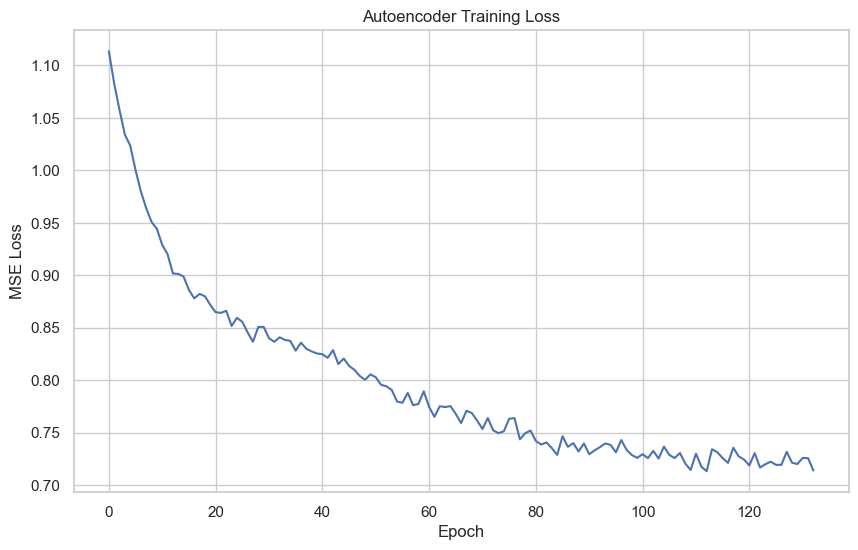

Contamination rate: 0.5756 | Anomaly Threshold: 0.578770

Autoencoder performance:
Precision: 0.7034
Recall: 0.6975
F1 Score: 0.7004


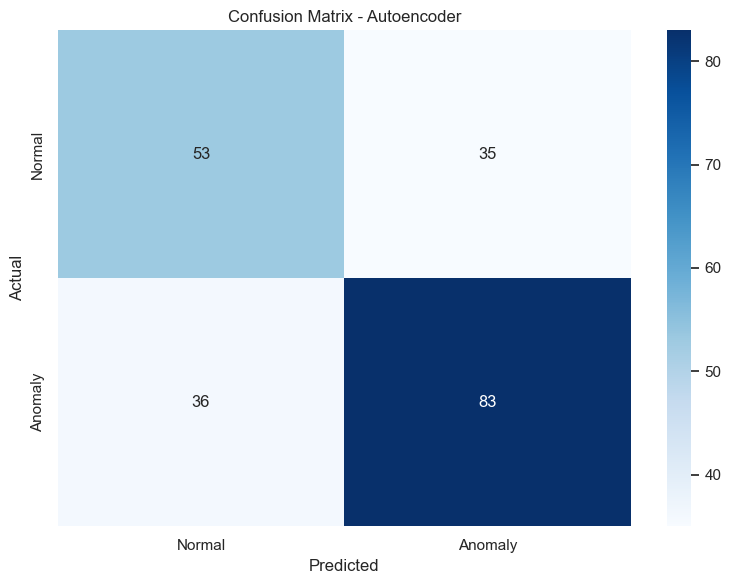

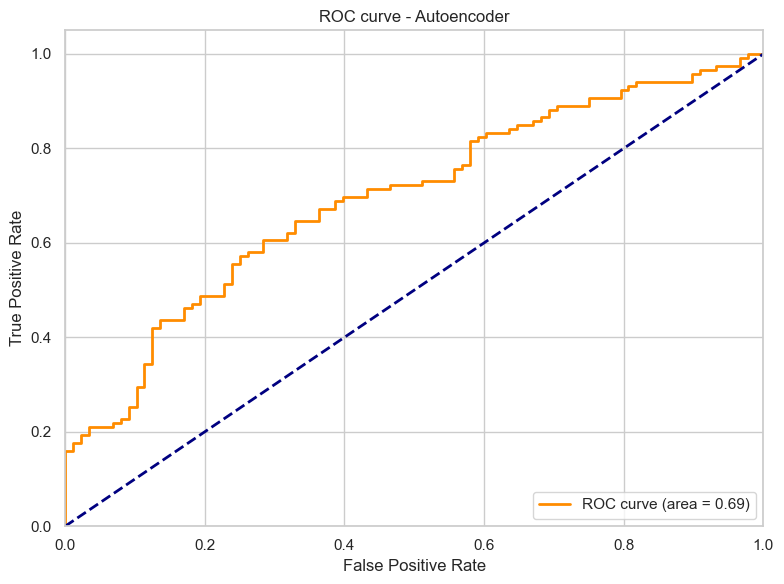

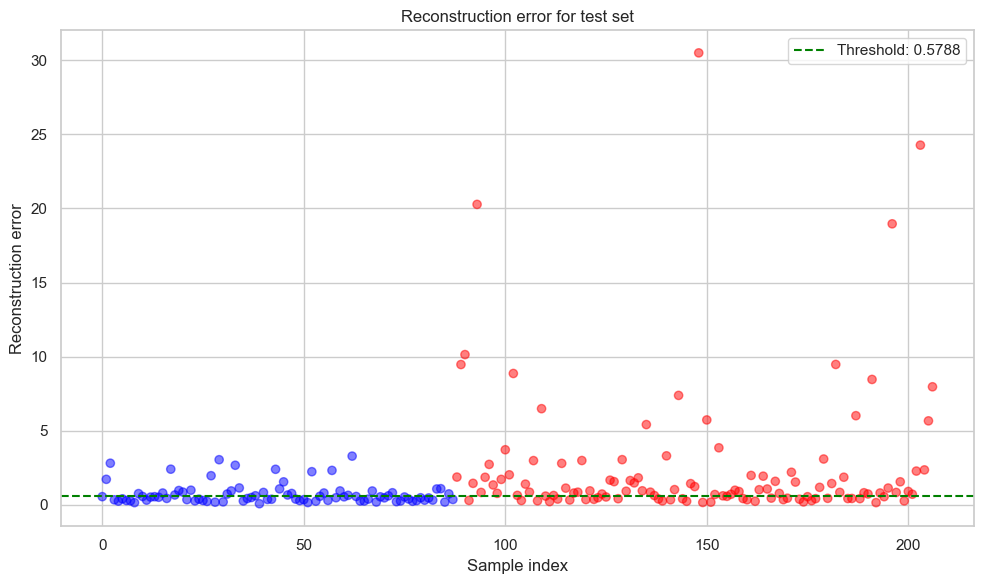

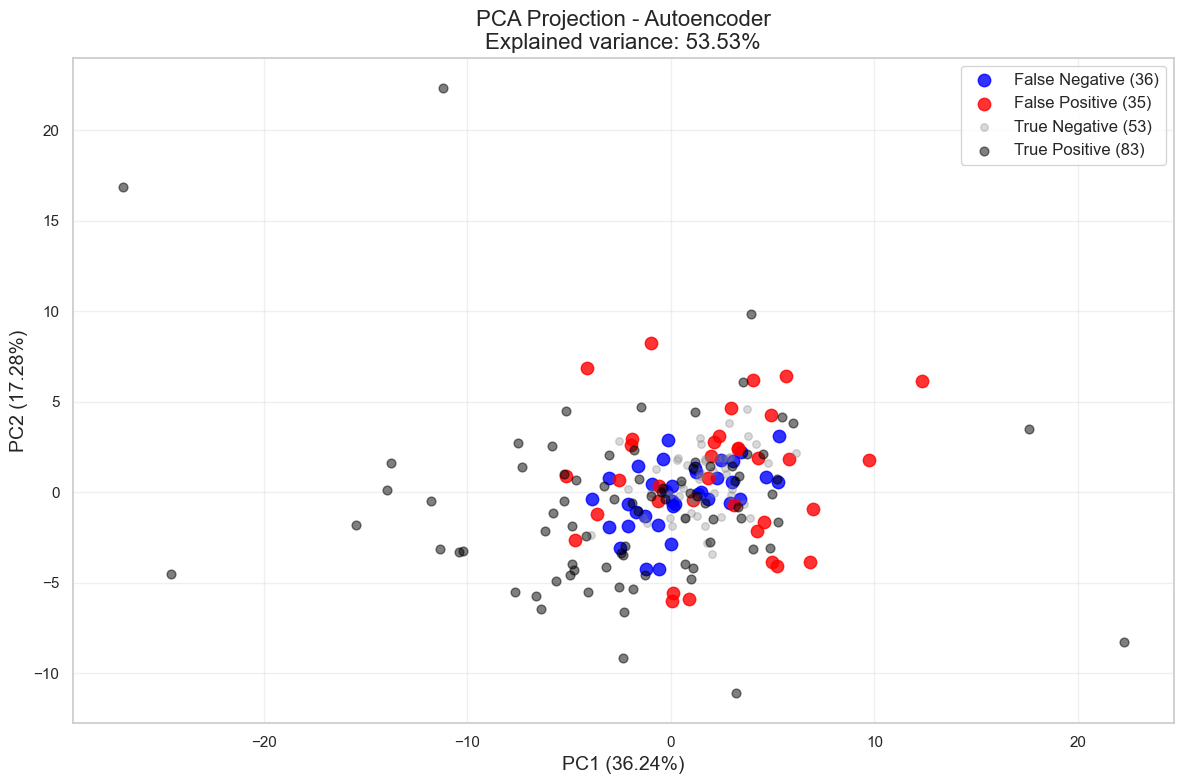

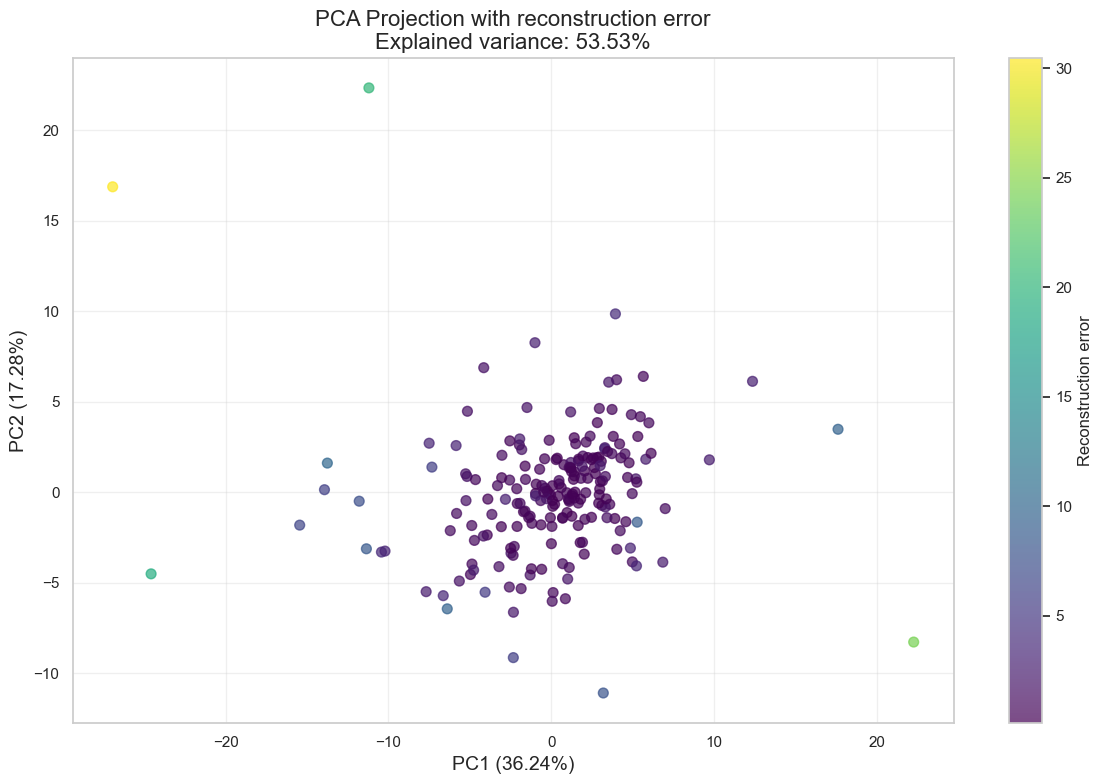

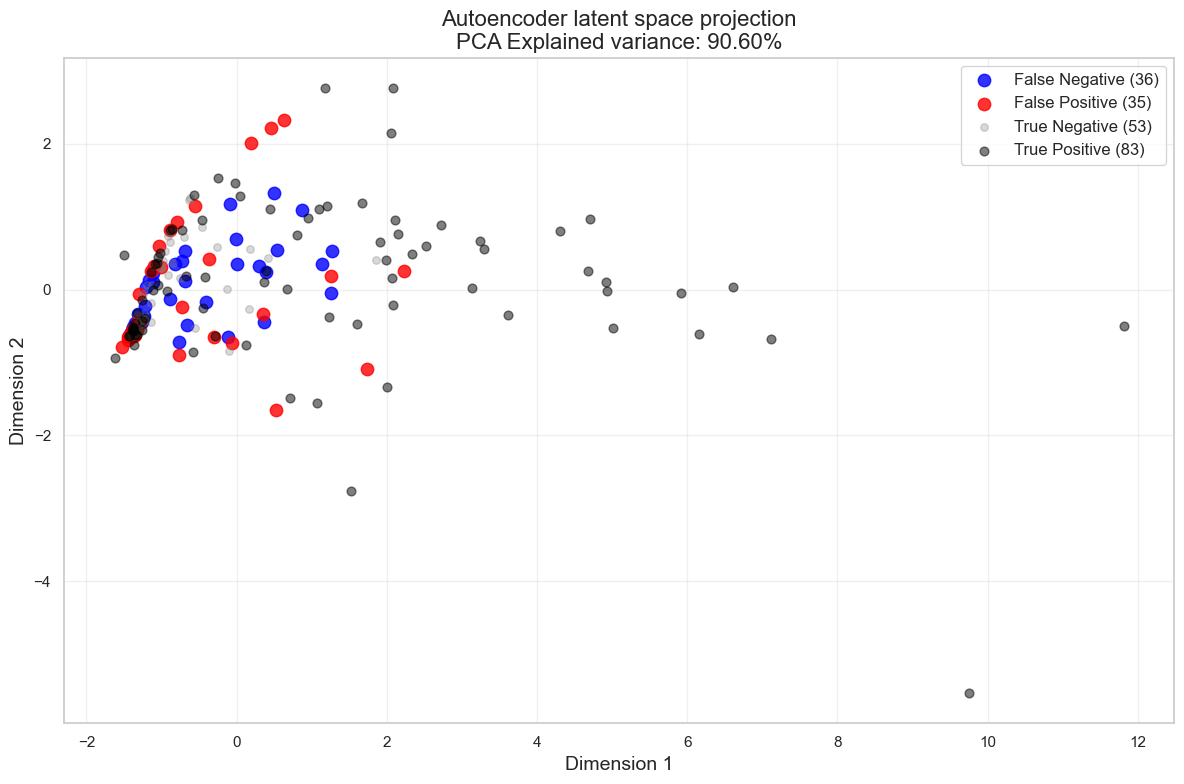

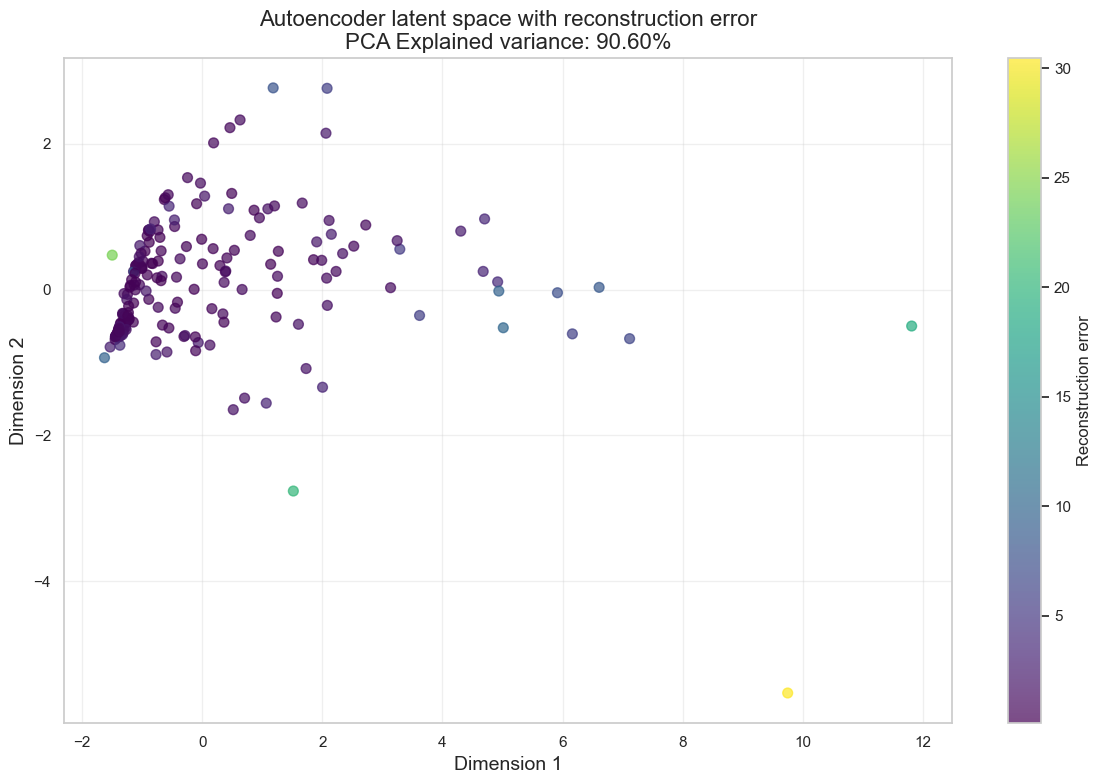

In [22]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor_filtered = torch.FloatTensor(X_train_scaled_filtered).to(device)
X_cv_tensor_filtered = torch.FloatTensor(X_cv_scaled_filtered).to(device)
X_test_tensor_filtered = torch.FloatTensor(X_test_scaled_filtered).to(device)

# Create DataLoaders
batch_size_filtered = 64
train_dataset_filtered = TensorDataset(X_train_tensor_filtered, X_train_tensor_filtered)
train_loader_filtered = DataLoader(train_dataset_filtered, batch_size=batch_size_filtered, shuffle=True)


# Create the autoencoder model
input_dim_filtered = X_train_scaled_filtered.shape[1]
encoding_dim_filtered = max(1, min(16, input_dim_filtered // 4))
model_filtered = Autoencoder(input_dim_filtered, encoding_dim_filtered).to(device)
print(f"Input dimension: {input_dim_filtered} | Bottleneck dimension: {encoding_dim_filtered}")

# Train the autoencoder
model_filtered = train_autoencoder(model_filtered, train_loader_filtered, num_epochs=200, patience=20)

# Compute reconstruction errors
cv_errors_filtered = compute_reconstruction_error(model_filtered, X_cv_tensor_filtered)
test_errors_filtered = compute_reconstruction_error(model_filtered, X_test_tensor_filtered)

# Set threshold at the percentile corresponding to the contamination rate
contamination_filtered = np.mean(y_cross_val_filtered)
threshold_filtered = np.percentile(cv_errors_filtered, 100 * (1 - contamination_filtered))
print(f"Contamination rate: {contamination_filtered:.4f} | Anomaly Threshold: {threshold_filtered:.6f}")

# Make predictions on test set
y_pred_filtered = (test_errors_filtered > threshold_filtered).astype(int)

# Plots
y_test_arr_filtered = np.array(y_test_filtered)
ae_metrics_filtered = evaluate_autoencoder(y_test_arr_filtered, y_pred_filtered, test_errors_filtered, threshold_filtered)
visualize_autoencoder_pca(model_filtered, X_test_tensor_filtered, X_test_scaled_filtered, y_test_arr_filtered, y_pred_filtered, test_errors_filtered)

### Autoencoder Results Comparison: Full Dateset and FIltered Dataser

After running the Autoencoder pipeline on both datasets, we can compare the classification performance on the test set. 

| Metric | Full Dataset | Filtered Dataset | Winner |
| :--- | :---: | :---: | :---: |
| **Precision** | 0.6960 | **0.7034** | Sparse |
| **Recall** | **0.7311** | 0.6975 | Dense |
| **F1-Score** | **0.7131** | 0.7004 | Dense |
| **ROC AUC** | **0.73** | 0.69 | Dense |

The Autoencoder performed better when provided with the full, unfiltered macroeconomic dataset (`stationary_df`). 

While the manual filtering of features (Sparse Hypothesis) slightly improved *Precision* (reducing false alarms), the full dataset allowed the neural network to capture the underlying market dynamics much better, resulting in a significantly higher *Recall* (catching more actual crises) and a better overall *ROC AUC* score. 


## Variational Autoencoder (VAE)

To improve upon the standard Autoencoder, we introduce a **Variational Autoencoder (VAE)**. While a standard Autoencoder maps input data to a fixed, deterministic vector in the latent space, a VAE maps inputs to a **probability distribution** (defined by a mean $\mu$ and a variance $\sigma^2$). 

This probabilistic approach offers several structural advantages for Anomaly Detection in financial time series **Robust Loss Function**: The VAE optimizes a dual-objective loss function:
   - **Reconstruction Loss (MSE)**: Measures how well the model reconstructs the original input.
   - **Kullback-Leibler (KL) Divergence**: Acts as a powerful regularizer, penalizing the model if its latent distributions deviate too much from a standard normal distribution.

We will run the VAE for both the full dataset and the filtered dataset


## VAE Full Dataset - `stationary_df`

Using device: cpu
Input dimension: 42 | Bottleneck dimension: 10
Training Variational Autoencoder...
Epoch 10/200, Loss: 39.521188
Epoch 20/200, Loss: 35.365074
Epoch 30/200, Loss: 33.468185
Epoch 40/200, Loss: 32.104174
Epoch 50/200, Loss: 31.363900
Epoch 60/200, Loss: 31.120557
Epoch 70/200, Loss: 30.017997
Epoch 80/200, Loss: 29.628569
Epoch 90/200, Loss: 29.880111
Epoch 100/200, Loss: 29.001145
Epoch 110/200, Loss: 29.122795
Epoch 120/200, Loss: 28.997233
Epoch 130/200, Loss: 28.840423
Early stopping at epoch 135


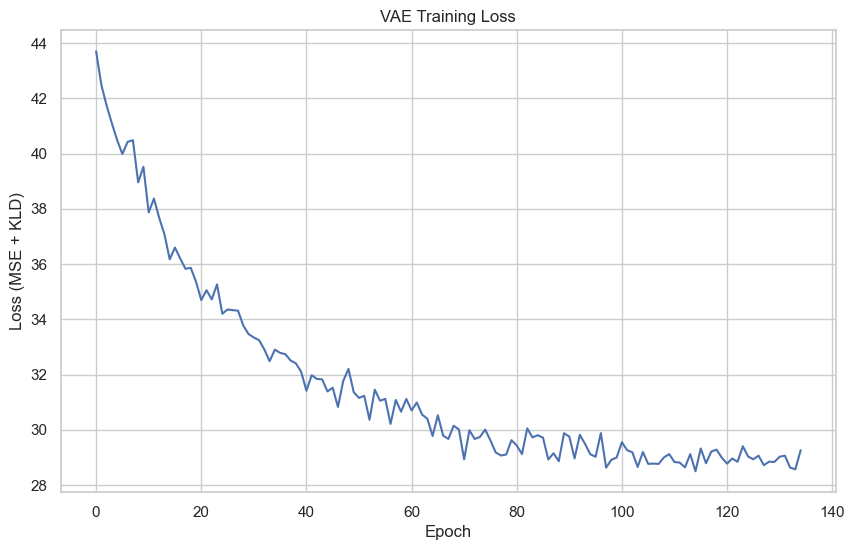

Contamination rate: 0.5756 | Anomaly Threshold: 0.460713

Autoencoder performance:
Precision: 0.6533
Recall: 0.8235
F1 Score: 0.7286


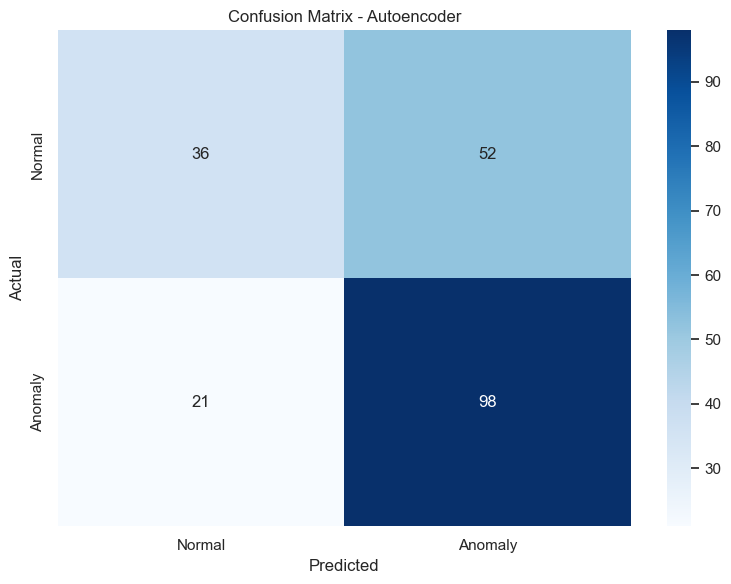

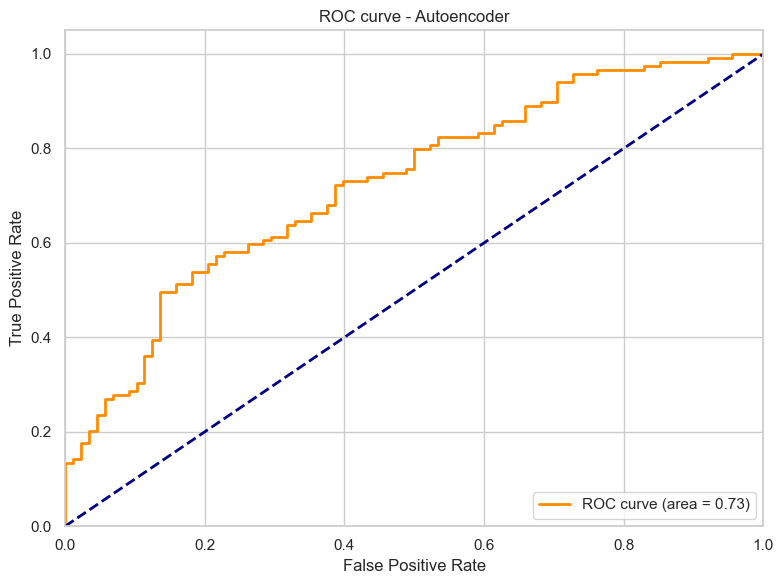

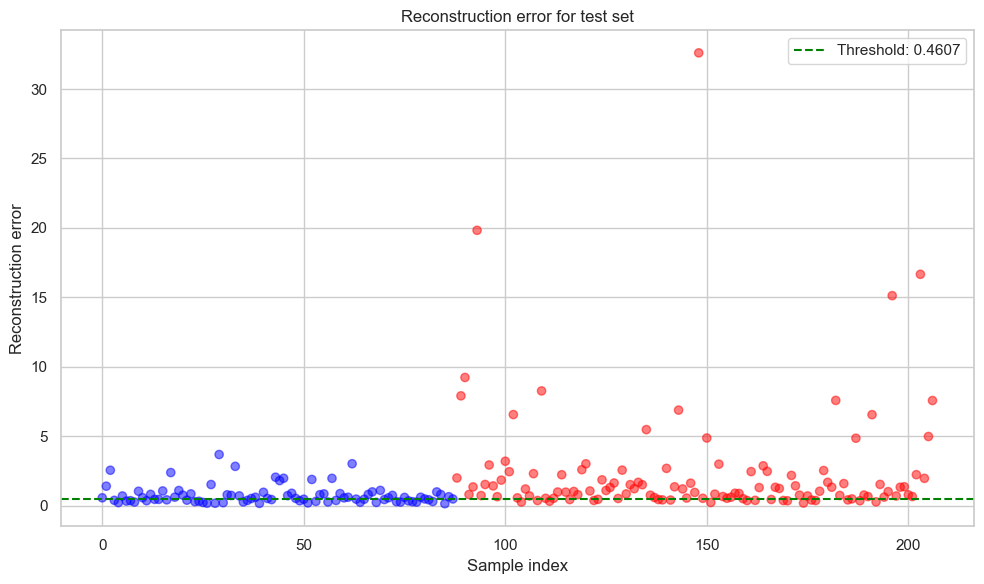

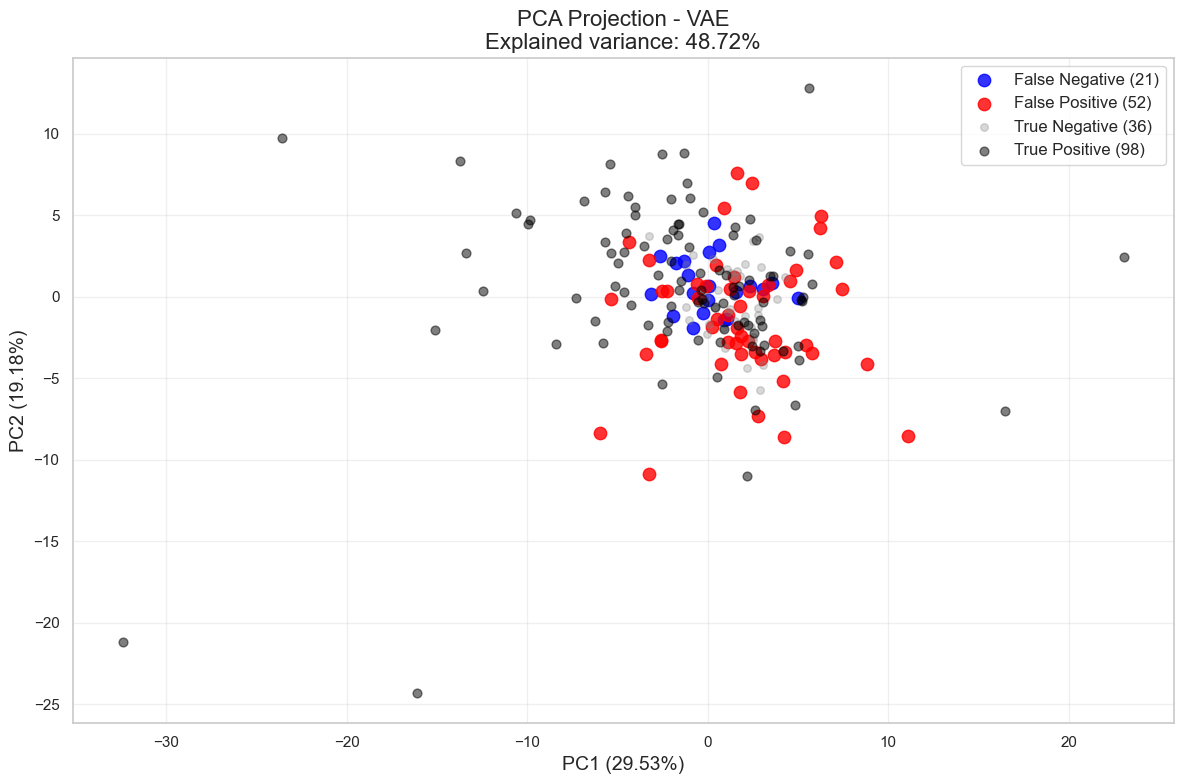

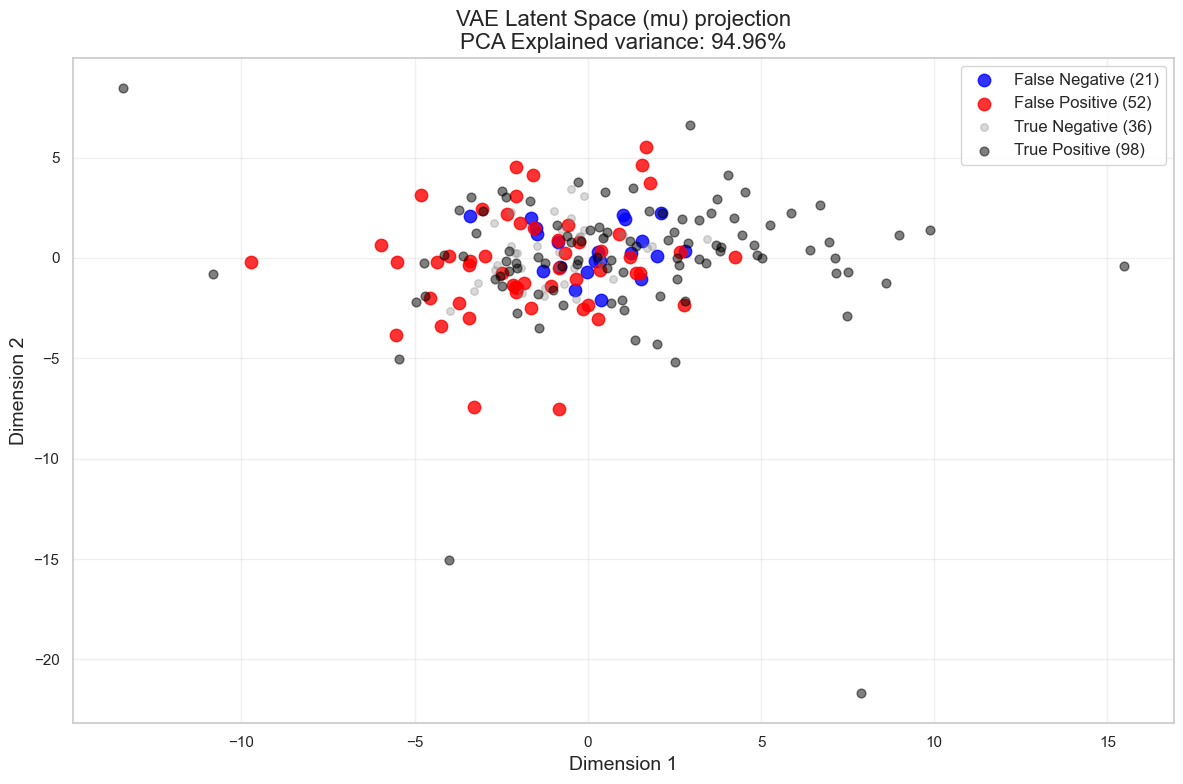

In [23]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_cv_tensor = torch.FloatTensor(X_cv_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
# AgAdd drop_last=True if last batch has only one element
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


# Create the Variational Autoencoder model (VAE)
input_dim = X_train_scaled.shape[1]
encoding_dim = max(1, min(16, input_dim // 4))
model = VariationalAutoencoder(input_dim, encoding_dim).to(device)
print(f"Input dimension: {input_dim} | Bottleneck dimension: {encoding_dim}")

# Train the VAE (usa la loss combinata MSE + KL Divergence)
model = train_vae(model, train_loader, num_epochs=200, patience=20)

# Compute reconstruction errors for VAE
cv_errors = compute_reconstruction_error_vae(model, X_cv_tensor)
test_errors = compute_reconstruction_error_vae(model, X_test_tensor)

# Set threshold 
# N.B. È matematicamente più corretto calcolare i percentili solo sugli errori normali del CV set
contamination = np.mean(y_cross_val)
cv_errors_normal = cv_errors[y_cross_val == 0]
threshold = np.percentile(cv_errors_normal, 100 * (1 - contamination))
print(f"Contamination rate: {contamination:.4f} | Anomaly Threshold: {threshold:.6f}")

# Make predictions on test set
y_pred = (test_errors > threshold).astype(int)

# Plots
y_test_arr = np.array(y_test)
# evaluate_autoencoder va benissimo anche per il VAE perché le metriche (F1, Precision) sono standard
ae_metrics = evaluate_autoencoder(y_test_arr, y_pred, test_errors, threshold)
# Nuova funzione di plot che mappa lo spazio latente in base alla "Media" (mu) generata dal VAE
visualize_vae_pca(model, X_test_tensor, X_test_scaled, y_test_arr, y_pred, test_errors) 


## VAE Filtered Dataset - `filtered_df`

Using device: cpu
Input dimension: 31 | Bottleneck dimension: 7
Training Variational Autoencoder...
Epoch 10/200, Loss: 29.278385
Epoch 20/200, Loss: 26.462876
Epoch 30/200, Loss: 25.863018
Epoch 40/200, Loss: 24.892853
Epoch 50/200, Loss: 24.957344
Epoch 60/200, Loss: 23.997037
Epoch 70/200, Loss: 23.294401
Epoch 80/200, Loss: 23.785046
Epoch 90/200, Loss: 22.979237
Epoch 100/200, Loss: 23.215236
Epoch 110/200, Loss: 22.414220
Epoch 120/200, Loss: 22.272298
Epoch 130/200, Loss: 22.526573
Epoch 140/200, Loss: 22.210737
Epoch 150/200, Loss: 22.623312
Epoch 160/200, Loss: 21.740565
Epoch 170/200, Loss: 21.958025
Epoch 180/200, Loss: 22.298987
Epoch 190/200, Loss: 21.652731
Epoch 200/200, Loss: 21.843055


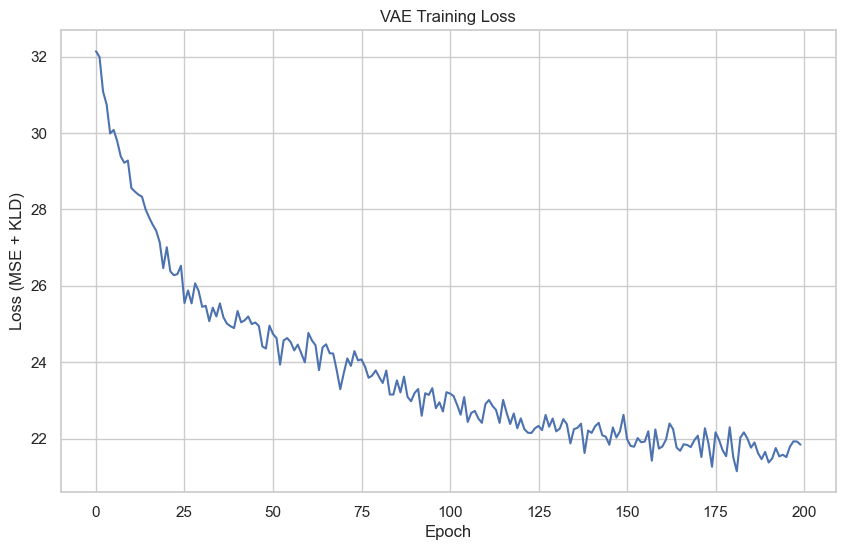

Contamination rate: 0.5756 | Anomaly Threshold: 0.418045

Autoencoder performance:
Precision: 0.6443
Recall: 0.8067
F1 Score: 0.7164


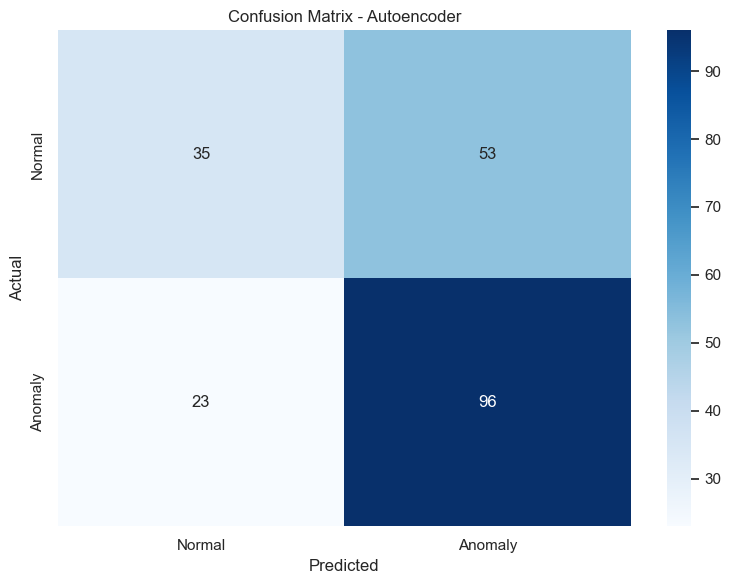

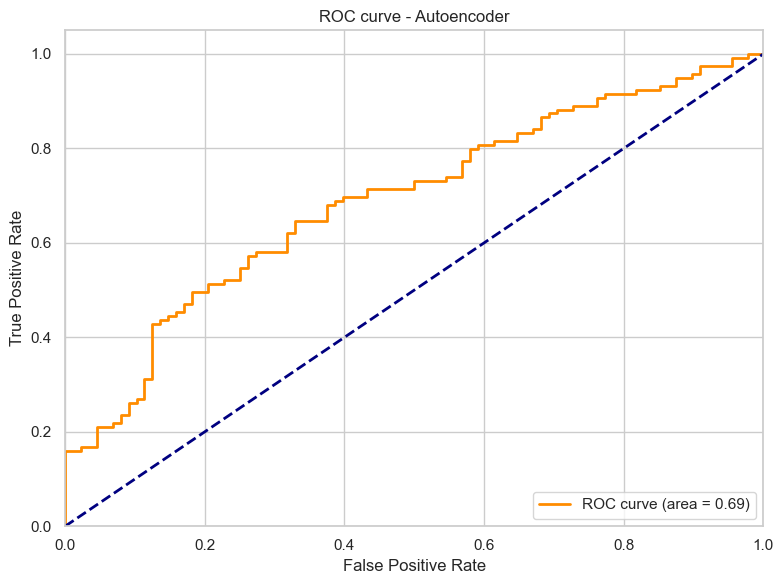

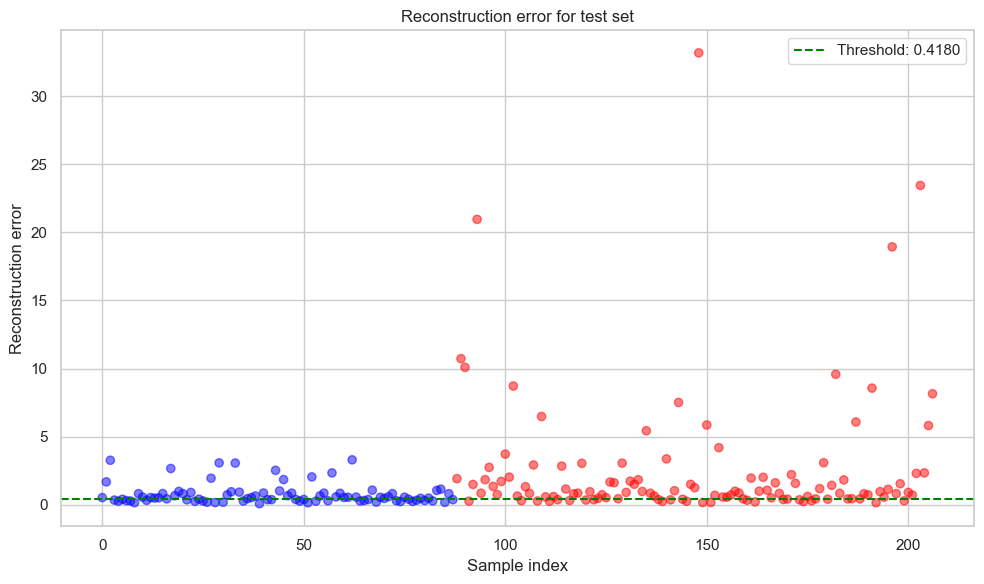

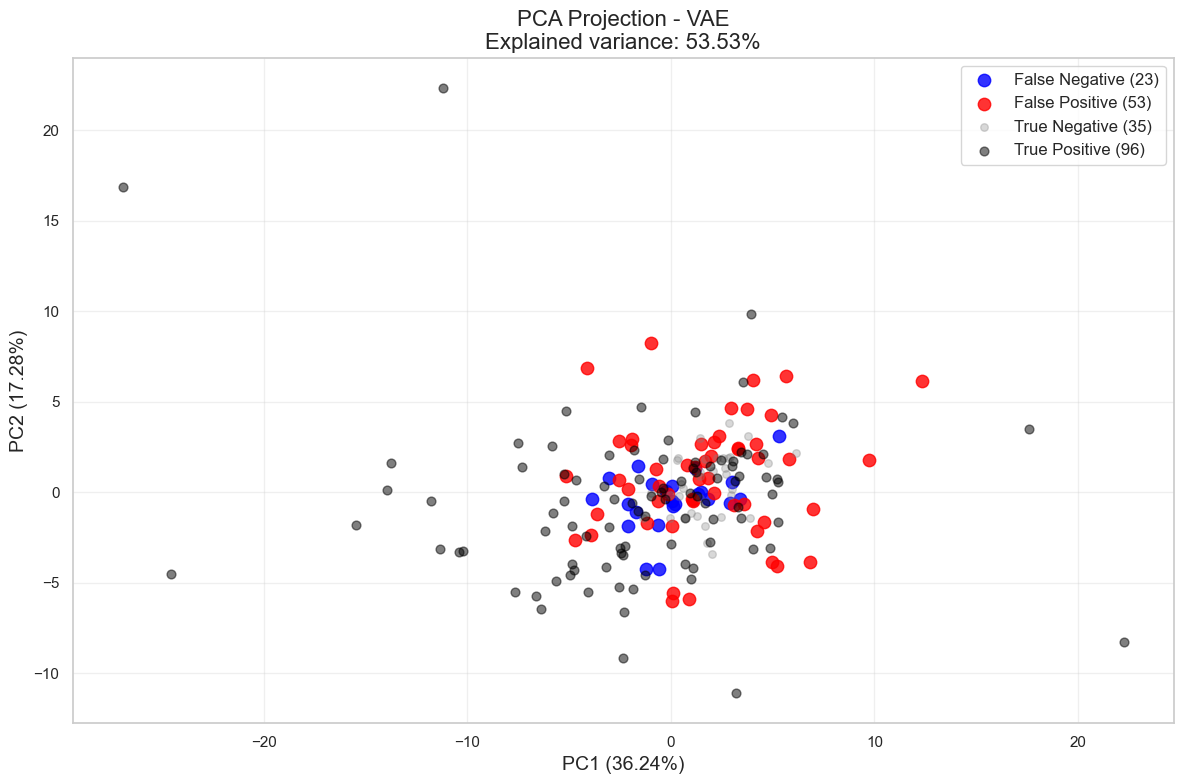

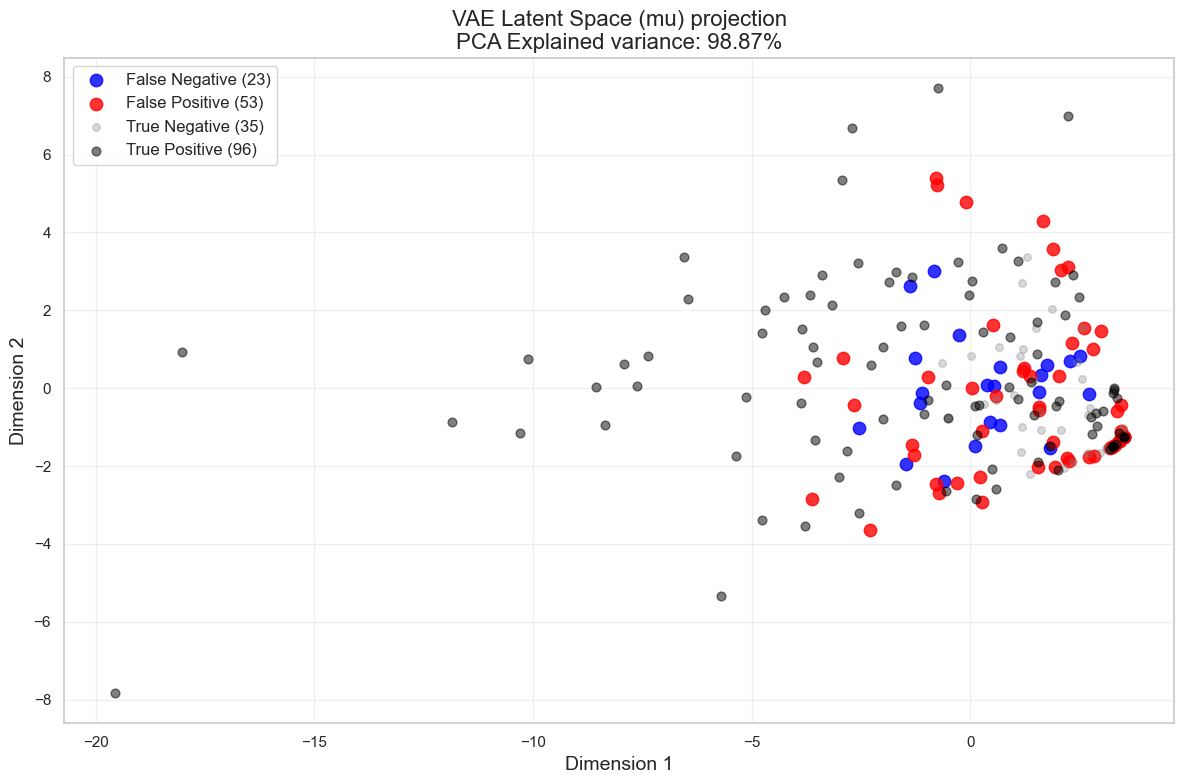

In [24]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor_filtered = torch.FloatTensor(X_train_scaled_filtered).to(device)
X_cv_tensor_filtered = torch.FloatTensor(X_cv_scaled_filtered).to(device)
X_test_tensor_filtered = torch.FloatTensor(X_test_scaled_filtered).to(device)

# Create DataLoaders
batch_size_filtered = 64
train_dataset_filtered = TensorDataset(X_train_tensor_filtered, X_train_tensor_filtered)
# Aggiunto drop_last=True per evitare crash se l'ultimo batch ha solo 1 elemento
train_loader_filtered = DataLoader(train_dataset_filtered, batch_size=batch_size_filtered, shuffle=True, drop_last=True)

# Create the Variational Autoencoder model (VAE)
input_dim_filtered = X_train_scaled_filtered.shape[1]
encoding_dim_filtered = max(1, min(16, input_dim_filtered // 4))
model_filtered = VariationalAutoencoder(input_dim_filtered, encoding_dim_filtered).to(device)
print(f"Input dimension: {input_dim_filtered} | Bottleneck dimension: {encoding_dim_filtered}")

# Train the VAE (usa la loss combinata MSE + KL Divergence)
model_filtered = train_vae(model_filtered, train_loader_filtered, num_epochs=200, patience=20)

# Compute reconstruction errors for VAE
cv_errors_filtered = compute_reconstruction_error_vae(model_filtered, X_cv_tensor_filtered)
test_errors_filtered = compute_reconstruction_error_vae(model_filtered, X_test_tensor_filtered)

# Set threshold 
# N.B. È matematicamente più corretto calcolare i percentili solo sugli errori normali del CV set
contamination_filtered = np.mean(y_cross_val_filtered)
cv_errors_normal_filtered = cv_errors_filtered[y_cross_val_filtered == 0]
threshold_filtered = np.percentile(cv_errors_normal_filtered, 100 * (1 - contamination_filtered))
print(f"Contamination rate: {contamination_filtered:.4f} | Anomaly Threshold: {threshold_filtered:.6f}")

# Make predictions on test set
y_pred_filtered = (test_errors_filtered > threshold_filtered).astype(int)

# Plots
y_test_arr_filtered = np.array(y_test_filtered)
# evaluate_autoencoder va benissimo anche per il VAE perché le metriche (F1, Precision) sono standard
ae_metrics_filtered = evaluate_autoencoder(y_test_arr_filtered, y_pred_filtered, test_errors_filtered, threshold_filtered)
# Nuova funzione di plot che mappa lo spazio latente in base alla "Media" (mu) generata dal VAE
visualize_vae_pca(model_filtered, X_test_tensor_filtered, X_test_scaled_filtered, y_test_arr_filtered, y_pred_filtered, test_errors_filtered) 

### Results: Autoencoder and Variational Autoencoder (VAE)

We compared the standard deterministic Autoencoder against a probabilistic Variational Autoencoder (VAE), across both Full Dataset Filtered Dataset.

| Metric | Autoencoder (Full) | Autoencoder (Filtered) | VAE (Full) | VAE (Filtered) | Overall Winner |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Precision** | 0.6960 | **0.7034** | 0.6533 | 0.6443 | AE (Filtered) |
| **Recall** | 0.7311 | 0.6975 | **0.8235** | 0.8067 | VAE (Full) |
| **F1-Score** | 0.7131 | 0.7004 | **0.7286** | 0.7164 | VAE (Full) |
| **ROC AUC** | **0.73** | 0.69 | **0.73** | 0.69 | AE / VAE (Full) |

Observations:

1. Regardless of the architecture (Standard AE or VAE), feeding the model the **Full Dataset** consistently yields better F1-Scores and ROC AUC. The macroeconomic forecasting relies on dense, latent factors distributed across many variables, rather than a few isolated "noisy" features.
   
2. While VAE loses a few percentage points in Precision (meaning slightly more "false alarms"), **VAE increases Recall** (from ~73% to ~82% on the full dataset). 

3. In the context of financial crisis prediction, **Recall is the most critical metric**. Failing to predict a market crash (False Negative) is exponentially more expensive for a portfolio than temporarily reducing exposure due to a false alarm (False Positive). The **VAE**'s probabilistic latent space structure makes it much more sensitive to true anomalies, yielding the highest overall F1-Score.
